FIS CODE

## 1. Setup

### 1.1 Data loading helpers (`data_prep`)

In [5]:
"""
data_prep.py
============
Loads the eight cleaned datasets used in the EDA, normalises column names,
and constructs derived series for forecasting.

All series are UK, annual frequency.
"""

import re
from pathlib import Path

import numpy as np
import pandas as pd


def _clean_col(c: str) -> str:
    """Normalise a column name: lowercase, snake_case, no awkward chars."""
    c = c.strip().lower()
    c = re.sub(r"[\n\r]+", "_", c)
    c = re.sub(r"[&%():/.\ -]", "_", c)
    c = re.sub(r"_+", "_", c)
    return c.strip("_")


def _load(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [_clean_col(c) for c in df.columns]
    return df


def load_all(data_dir: str | Path) -> dict[str, pd.DataFrame]:
    """
    Load every cleaned CSV. Returns a dictionary keyed by short name.
    """
    data_dir = Path(data_dir)
    return {
        "infrastructure": _load(data_dir / "banking_infrastructure_df.csv"),
        "balance":        _load(data_dir / "df_balance_clean.csv"),
        "interest":       _load(data_dir / "df_interest_clean.csv"),
        "open_account":   _load(data_dir / "df_open_account_clean.csv"),
        "cass":           _load(data_dir / "df_cass_annual_clean.csv"),
        "fraud":          _load(data_dir / "df_fraud_clean.csv"),
        "contactless":    _load(data_dir / "df_contactless_clean.csv"),
        "payments":       _load(
            data_dir / "uk_total_payments_by_method_annual_volume_2014_2024_billions.csv"
        ),
    }


def build_payments_features(payments: pd.DataFrame) -> pd.DataFrame:
    """
    Build derived features on the payments dataset.

    Notes
    -----
    `contactless_subset_of_cards` is a subset of debit + credit volumes.
    For share-of-mix calculations we use the seven non-overlapping methods:
    debit_card, credit_card, cash, direct_debit, faster_payments_remote_banking,
    bacs_direct_credit, standing_order. Contactless is analysed separately as
    a within-cards share.
    """
    df = payments.copy().sort_values("year").reset_index(drop=True)

    contactless_col = next(c for c in df.columns if "contactless" in c)
    total_col       = next(c for c in df.columns if "total" in c)

    method_cols = [
        c for c in df.columns
        if c not in ("year", contactless_col, total_col)
    ]

    df["card_total"] = df["debit_card"] + df["credit_card"]
    df["method_sum"] = df[method_cols].sum(axis=1)

    # Shares
    for c in method_cols:
        df[f"{c}_share"] = df[c] / df["method_sum"]

    df["contactless_share_of_cards"] = df[contactless_col] / df["card_total"]

    return df


def build_atm_features(infra: pd.DataFrame) -> pd.DataFrame:
    """Add ATM-share features."""
    df = infra.copy().sort_values("year").reset_index(drop=True)
    df["free_atm_share"] = df["free_atm_count"] / df["total_atm_count"]
    df["fee_atm_share"]  = df["transaction_fee_atm_count"] / df["total_atm_count"]
    return df


def build_fraud_features(fraud: pd.DataFrame) -> pd.DataFrame:
    """Add fraud-composition features."""
    df = fraud.copy().sort_values("year").reset_index(drop=True)
    cnp_col = next(c for c in df.columns if "remote_purchase" in c or "cnp" in c)
    df["cnp_share_of_total"] = df[cnp_col] / df["total_card_fraud"]
    df["counterfeit_share_of_total"] = df["counterfeit_card"] / df["total_card_fraud"]
    return df


def drop_covid_year(df: pd.DataFrame, year_col: str = "year",
                    covid_year: int = 2020) -> pd.DataFrame:
    """
    Drop a single COVID-affected year from a series, per project decision
    to fit payment-method models on the rest.
    """
    return df[df[year_col] != covid_year].copy()


def covid_pandemic_dummy(years: pd.Series, covid_years=(2020, 2021)) -> pd.Series:
    """Return a 0/1 dummy for COVID-pandemic years."""
    return years.isin(covid_years).astype(int)


__all__ = [
    "load_all",
    "build_payments_features",
    "build_atm_features",
    "build_fraud_features",
    "drop_covid_year",
    "covid_pandemic_dummy",
]


### 1.2 Imports, FIS palette, matplotlib defaults

In [6]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.stattools import (
    durbin_watson, jarque_bera, omni_normtest
)

# ---------------------------------------------------------------------------
# FIS brand palette
# ---------------------------------------------------------------------------
FIS = {
    "dark_green":  "#012834",   # primary actuals / single-line charts
    "green":       "#4BCD3E",   # positive / growth / "with guarantee"
    "red":         "#FF1F3E",   # negative / decline / "without guarantee"
    "blue":        "#285BC5",   # secondary line / paired series
    "dark_blue":   "#1B1B6F",   # credit card
    "light_blue":  "#3BCFF0",   # tertiary
    "teal":        "#015B7E",
    "purple":      "#A18CDE",
    "deep_purple": "#4C12A1",   # remote/CNP fraud
    "orange":      "#FD8D62",   # faster payments
    "amber":       "#FFC845",
    "olive":       "#CC9E00",
    "neutral":     "#9CA3AF",
    "panel_bg":    "#F9F5F1",   # FIS light neutral
}

# Per-payment-method colour mapping (used in sections 3 and 4)
PAYMENT_COLOR = {
    "Cash":            FIS["dark_green"],
    "Debit card":      FIS["blue"],
    "Credit card":     FIS["dark_blue"],
    "Contactless":     FIS["green"],
    "Faster payments": FIS["orange"],
    "Bacs DC":         FIS["neutral"],
    "Direct debit":    FIS["olive"],
    "Standing order":  FIS["light_blue"],
    "Total fraud":     FIS["red"],
    "Remote (CNP)":    FIS["deep_purple"],
}

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "semibold",
    "axes.titlesize": 12,
    "font.size": 10,
    "legend.frameon": True,
})


### 1.3 Event-line and save helpers

In [7]:
def add_event_lines(ax, xmin, xmax):
    """Add the three event markers used in the banking EDA charts."""
    events = {
        2008: "Financial crisis",
        2020: "COVID-19",
        2022: "Rate rises",
    }
    for year, label in events.items():
        if xmin <= year <= xmax:
            ax.axvline(year, linestyle="--", linewidth=1,
                       alpha=0.5, color=FIS["dark_green"])
            ymax = ax.get_ylim()[1]
            ax.text(year + 0.1, ymax * 0.95, label,
                    rotation=90, va="top", fontsize=8, alpha=0.8,
                    color=FIS["dark_green"])


# Two output directories — banking vs payments
OUT_DIR_BANKING  = "charts_eda_fis"
OUT_DIR_PAYMENTS = "charts_payments_eda_fis"
os.makedirs(OUT_DIR_BANKING, exist_ok=True)
os.makedirs(OUT_DIR_PAYMENTS, exist_ok=True)


def save(name, out_dir=OUT_DIR_BANKING, dpi=130):
    """Save the current figure, tight bounding box, then close."""
    path = f"{out_dir}/{name}"
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close()
    return path


### 1.4 Load datasets

In [8]:
raw = load_all("data")
infra    = raw["infrastructure"]
balance  = raw["balance"]
interest = raw["interest"]
cass     = raw["cass"]
fraud    = raw["fraud"].sort_values("year").reset_index(drop=True)
payments = build_payments_features(raw["payments"])

print("Loaded datasets:")
for k, v in raw.items():
    print(f"  {k:15s}  shape={v.shape}, years={int(v['year'].min())}-{int(v['year'].max())}")


Loaded datasets:
  infrastructure   shape=(26, 7), years=2000-2025
  balance          shape=(26, 3), years=2000-2025
  interest         shape=(25, 2), years=2001-2025
  open_account     shape=(81, 5), years=2019-2026
  cass             shape=(5, 4), years=2021-2025
  fraud            shape=(13, 10), years=2012-2024
  contactless      shape=(7, 5), years=2007-2026
  payments         shape=(11, 10), years=2014-2024


---
## 2. Banking EDA charts — sections 4.1-4.3 and 5.1-5.3

Generates 11 charts into `charts_eda_fis/`. Colour scheme:
- **FIS Dark Green** — primary actuals / single-line charts
- **FIS Green** — positive / growth / with-guarantee series
- **FIS Red** — decline / without-guarantee series
- **FIS Blue** — secondary line on paired series (interest rate)
- Heatmap uses FIS Blue ↔ White ↔ FIS Red (coolwarm-equivalent)

### 2.1 Banking infrastructure trends (section 4.1)

In [9]:
# --- Bank branches over time ---------------------------------------------
df = infra.sort_values("year").copy()
fig, ax = plt.subplots()
ax.plot(df["year"], df["bank_branches_count"],
        marker="o", color=FIS["dark_green"], linewidth=2,
        label="bank_branches_count")
ax.set_title("Bank branches over time")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=8))
ax.set_xlim(df["year"].min(), df["year"].max())
ax.legend(loc="lower left")
add_event_lines(ax, df["year"].min(), df["year"].max())
save("banking_infrastructure_trends_bank_branches_over_time.png")

# --- Number of banks over time -------------------------------------------
df = infra.sort_values("year").copy()
fig, ax = plt.subplots()
ax.plot(df["year"], df["number_of_banks_uk"],
        marker="o", color=FIS["dark_green"], linewidth=2,
        label="number_of_banks_uk")
ax.set_title("Number of banks in the UK over time")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=8))
ax.set_xlim(df["year"].min(), df["year"].max())
ax.legend(loc="lower left")
add_event_lines(ax, df["year"].min(), df["year"].max())
save("banking_infrastructure_trends_number_of_banks_over_time.png")

# --- ATM share -----------------------------------------------------------
df = infra.copy().sort_values("year")
df["free_atm_share"] = df["free_atm_count"] / df["total_atm_count"]
df["fee_atm_share"]  = df["transaction_fee_atm_count"] / df["total_atm_count"]
fig, ax = plt.subplots()
ax.plot(df["year"], df["free_atm_share"],
        marker="o", color=FIS["green"], linewidth=2, label="free_atm_share")
ax.plot(df["year"], df["fee_atm_share"],
        marker="o", color=FIS["red"], linewidth=2, label="fee_atm_share")
ax.set_title("Free vs fee-charging ATM share")
ax.set_xlabel("year")
ax.set_ylabel("Share of total ATMs")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=8))
ax.set_xlim(df["year"].min(), df["year"].max())
ax.legend(loc="center left")
add_event_lines(ax, df["year"].min(), df["year"].max())
save("banking_infrastructure_trends_atm_fee_share.png")
print("Section 4.1 done: 3 charts")


Section 4.1 done: 3 charts


### 2.2 Customer behaviour indicators (section 4.2)

In [10]:
# --- Total CASS switches over time ---------------------------------------
df = cass.sort_values("year")
fig, ax = plt.subplots()
ax.plot(df["year"], df["total_switches"],
        marker="o", color=FIS["dark_green"], linewidth=2,
        label="total_switches")
ax.set_title("Total Current Account Switches Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Number of switches")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=8))
ax.set_xlim(df["year"].min(), df["year"].max())
ax.legend(loc="upper right")
add_event_lines(ax, df["year"].min(), df["year"].max())
save("customer_behaviour_indicators_total_current_account_switches.png")

# --- Composition of switches (stacked bar) -------------------------------
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(df["year"].astype(str), df["switches_with_guarantee"],
       color=FIS["dark_green"], label="switches_with_guarantee")
ax.bar(df["year"].astype(str), df["switches_without_guarantee"],
       bottom=df["switches_with_guarantee"],
       color=FIS["red"], label="switches_without_guarantee")
ax.set_title("Composition of Current Account Switches")
ax.set_xlabel("Year")
ax.set_ylabel("Number of switches")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
save("customer_behaviour_indicators_composition_account_switches.png")
print("Section 4.2 done: 2 charts")


Section 4.2 done: 2 charts


### 2.3 Interest rates and deposit behaviour (section 4.3)

In [11]:
# --- Yearly deposit balance ----------------------------------------------
df = balance.sort_values("year")
fig, ax = plt.subplots()
ax.plot(df["year"], df["yearly_deposit_balance"],
        marker="o", color=FIS["dark_green"], linewidth=2,
        label="yearly_deposit_balance")
ax.set_title("Yearly deposit balance over time")
ax.set_xlabel("Year")
ax.set_ylabel("Balance")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=8))
ax.set_xlim(df["year"].min(), df["year"].max())
ax.legend(loc="upper left")
add_event_lines(ax, df["year"].min(), df["year"].max())
save("interest_rates_and_deposit_behaviour_yearly_deposit_balance.png")

# --- Interest rate vs deposit (scatter) ----------------------------------
balance_interest = balance.merge(interest, on="year", how="inner").dropna(
    subset=["bank_interest_rate", "yearly_deposit_balance"]
)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(balance_interest["bank_interest_rate"],
           balance_interest["yearly_deposit_balance"],
           color=FIS["dark_green"], s=40, alpha=0.85)
ax.set_title("Interest rate vs deposit balance")
ax.set_xlabel("Bank interest rate (%)")
ax.set_ylabel("Yearly deposit balance")
save("interest_rates_and_deposit_behaviour_interest_rate_vs_deposit.png")
print("Section 4.3 done: 2 charts")


Section 4.3 done: 2 charts


### 2.4 Shift from physical to digital banking (section 5.1)

In [12]:
combined = infra.merge(raw["payments"], on="year", how="inner").sort_values("year")

# --- Bank branches vs faster payments ------------------------------------
fig, ax1 = plt.subplots()
ax1.plot(combined["year"], combined["bank_branches_count"],
         marker="o", color=FIS["dark_green"], linewidth=2,
         label="Bank branches")
ax1.set_xlabel("Year")
ax1.set_ylabel("Bank branches")
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=8))

ax2 = ax1.twinx()
ax2.grid(False)
ax2.plot(combined["year"], combined["faster_payments_remote_banking"],
         marker="s", color=FIS["green"], linewidth=2,
         label="Faster payments & remote banking")
ax2.set_ylabel("Volume (billions)")

ax1.set_title("Bank branches vs faster payments and remote banking")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
save("shift_from_physical_to_digital_banking_bank_branches_vs_faster_payments.png")

# --- Bank branches vs cash volume ----------------------------------------
fig, ax1 = plt.subplots()
ax1.plot(combined["year"], combined["bank_branches_count"],
         marker="o", color=FIS["dark_green"], linewidth=2,
         label="Bank branches")
ax1.set_xlabel("Year")
ax1.set_ylabel("Bank branches")
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=8))

ax2 = ax1.twinx()
ax2.grid(False)
ax2.plot(combined["year"], combined["cash"],
         marker="s", color=FIS["red"], linewidth=2,
         label="Cash payments")
ax2.set_ylabel("Cash payment volume (billions)")

ax1.set_title("Bank branches and cash payment volume")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
save("shift_from_physical_to_digital_banking_bank_branches_vs_cash_volume.png")
print("Section 5.1 done: 2 charts")


Section 5.1 done: 2 charts


### 2.5 Macroeconomic influence (section 5.2)

In [13]:
# Merge and keep rows with both deposit balance AND bank rate
combined_macro = balance.merge(interest, on="year", how="inner").dropna(
    subset=["yearly_deposit_balance", "bank_interest_rate"]
)

fig, ax1 = plt.subplots()
ax1.plot(combined_macro["year"], combined_macro["yearly_deposit_balance"],
         marker="o", color=FIS["dark_green"], linewidth=2,
         label="Deposit balance")
ax1.set_xlabel("Year")
ax1.set_ylabel("Yearly deposit balance")
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=8))

ax2 = ax1.twinx()
ax2.grid(False)
ax2.plot(combined_macro["year"], combined_macro["bank_interest_rate"],
         marker="s", color=FIS["blue"], linewidth=2,
         label="Bank interest rate")
ax2.set_ylabel("Bank interest rate (%)")

ax1.set_title("Deposit balance and bank interest rate over time")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
save("macroeconomic_influence_deposit_and_bank_interest.png")
print("Section 5.2 done: 1 chart (regression visualization in section 4)")


Section 5.2 done: 1 chart (regression visualization in section 4)


### 2.6 Correlation matrix analysis (section 5.3)

In [14]:
combined_corr_df = infra.merge(raw["payments"], on="year", how="inner")
selected = [
    "bank_branches_count",
    "cash",
    "debit_card",
    "contactless_subset_of_cards",
    "faster_payments_remote_banking",
]
display_names = {"contactless_subset_of_cards": "contactless"}
sub = combined_corr_df[selected].dropna()
mat = sub.corr()
mat.index = mat.columns = [display_names.get(c, c) for c in mat.columns]

# FIS coolwarm-equivalent: FIS blue ↔ white ↔ FIS red
fis_coolwarm = LinearSegmentedColormap.from_list(
    "fis_coolwarm", [FIS["blue"], "#FFFFFF", FIS["red"]], N=256
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(mat, annot=True, fmt=".2f", cmap=fis_coolwarm,
            vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": 0.8},
            annot_kws={"fontsize": 10},
            ax=ax)
ax.set_title("Correlation between banking infrastructure and payment behaviour")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
save("correlation_matrix_analysis_correlation_banking_payment.png")
print("Section 5.3 done: 1 chart")
print("\nBanking EDA complete: 11 charts in charts_eda_fis/")


Section 5.3 done: 1 chart

Banking EDA complete: 11 charts in charts_eda_fis/


---
## 3. Payments EDA charts — sections 4.4-4.6 and 5.4-5.6

Generates 9 charts into `charts_payments_eda_fis/`. Per-payment-method
colours kept consistent across all panels:

| Method | Colour |
|---|---|
| Cash | FIS Dark Green |
| Debit / Card total | FIS Blue |
| Credit card | FIS Dark Blue |
| Contactless | FIS Green |
| Faster payments | FIS Orange |
| Direct debit / Bacs / Standing order | olive / grey / light blue |
| Total fraud | FIS Red |
| Remote CNP fraud | FIS Deep Purple |

### 3.1 Setup — payment colour map and derived columns

In [15]:
# Cleaned dataframes (build_payments_features already added card_total / shares)
contactless_df = raw["contactless"]
payments_df    = raw["payments"].sort_values("year").reset_index(drop=True)

CONTACTLESS_COL = [c for c in payments_df.columns if "contactless" in c][0]
TOTAL_COL       = [c for c in payments_df.columns if "total" in c][0]
METHOD_COLS     = [c for c in payments_df.columns
                   if c not in ("year", CONTACTLESS_COL, TOTAL_COL)]

payments_df["card_total"] = payments_df["debit_card"] + payments_df["credit_card"]
payments_df["method_sum"] = payments_df[METHOD_COLS].sum(axis=1)
payments_df["contactless_share_of_cards_pct"] = (
    payments_df[CONTACTLESS_COL] / payments_df["card_total"] * 100
)

# Per-column colour map + display labels
COLOR_MAP_COLS = {
    "debit_card":                     PAYMENT_COLOR["Debit card"],
    "credit_card":                    PAYMENT_COLOR["Credit card"],
    "cash":                           PAYMENT_COLOR["Cash"],
    "direct_debit":                   PAYMENT_COLOR["Direct debit"],
    "faster_payments_remote_banking": PAYMENT_COLOR["Faster payments"],
    "bacs_direct_credit":             PAYMENT_COLOR["Bacs DC"],
    "standing_order":                 PAYMENT_COLOR["Standing order"],
    "card_total":                     PAYMENT_COLOR["Debit card"],
}
LABEL_COLS = {
    "debit_card":                        "Debit card",
    "credit_card":                       "Credit card",
    "cash":                              "Cash",
    "direct_debit":                      "Direct debit",
    "faster_payments_remote_banking":    "Faster payments & remote banking",
    "bacs_direct_credit":                "Bacs direct credit",
    "standing_order":                    "Standing order",
    "card_total":                        "Card total (debit + credit)",
}

LABEL     = {**LABEL_COLS,     CONTACTLESS_COL: "Contactless (subset of cards)"}
COLOR_MAP = {**COLOR_MAP_COLS, CONTACTLESS_COL: PAYMENT_COLOR["Contactless"]}

print("Payments setup OK")
print(f"  Methods:     {METHOD_COLS}")
print(f"  Contactless: {CONTACTLESS_COL}")


Payments setup OK
  Methods:     ['debit_card', 'credit_card', 'cash', 'direct_debit', 'faster_payments_remote_banking', 'bacs_direct_credit', 'standing_order']
  Contactless: contactless_subset_of_cards


### 3.2 Overall payment behaviour trends (section 4.4) — Figure 8

In [16]:
fig, ax = plt.subplots(figsize=(13, 7))
for col in METHOD_COLS + [CONTACTLESS_COL]:
    ls = "--" if col == CONTACTLESS_COL else "-"
    ax.plot(payments_df["year"], payments_df[col],
            marker="o", label=LABEL.get(col, col),
            color=COLOR_MAP.get(col), linestyle=ls, linewidth=2)

ax.set_title("UK Annual Payment Volumes by Method, 2014-2024")
ax.set_xlabel("Year")
ax.set_ylabel("Volume (billions of transactions)")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
save("overall_payment_behaviour_trends_cash_decline_card_rise.png",
     out_dir=OUT_DIR_PAYMENTS, dpi=140)
print("Section 4.4 done: 1 chart (Fig 8)")


Section 4.4 done: 1 chart (Fig 8)


### 3.3 Payment method composition (section 4.5) — Figure 9

In [17]:
share = payments_df[["year"] + METHOD_COLS].copy()
for col in METHOD_COLS:
    share[col + "_share"] = payments_df[col] / payments_df["method_sum"] * 100

share_cols = [c + "_share" for c in METHOD_COLS]
share_plot = share[["year"] + share_cols].set_index("year")
share_plot.columns = [LABEL.get(c.replace("_share", ""), c.replace("_share", ""))
                      for c in share_cols]
colors_stack = [COLOR_MAP.get(c.replace("_share", ""), "#aaa") for c in share_cols]

fig, ax = plt.subplots(figsize=(13, 7))
ax.stackplot(share_plot.index,
             [share_plot[col] for col in share_plot.columns],
             labels=share_plot.columns, colors=colors_stack, alpha=0.88)
ax.set_title("UK Payment Method Share Over Time "
             "(Stacked, Contactless Excluded from Denominator)")
ax.set_xlabel("Year")
ax.set_ylabel("Share (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
save("payment_method_composition_uk_payment_method_share.png",
     out_dir=OUT_DIR_PAYMENTS, dpi=140)
print("Section 4.5 done: 1 chart (Fig 9)")


Section 4.5 done: 1 chart (Fig 9)


### 3.4 Growth rates and inflection points (section 4.6) — Figures 10 & 11

In [18]:
# --- Figure 10: YoY growth lines with COVID shading ----------------------
YOY_COLS = ["debit_card", "credit_card", "cash", CONTACTLESS_COL,
            "faster_payments_remote_banking", "card_total"]

yoy = payments_df[["year"] + YOY_COLS].copy()
for col in YOY_COLS:
    yoy[col + "_yoy"] = yoy[col].pct_change() * 100

fig, ax = plt.subplots(figsize=(13, 7))
for col in YOY_COLS:
    ax.plot(yoy["year"], yoy[col + "_yoy"],
            marker="o", linewidth=2,
            label=LABEL.get(col, col), color=COLOR_MAP.get(col))
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.axvspan(2019.5, 2020.5, alpha=0.10, color=FIS["red"])
ax.text(2020, ax.get_ylim()[0] + 0.5, "COVID-19",
        fontsize=9, color=FIS["red"], ha="center")
ax.set_title("YoY Growth Rate by Payment Method (%)")
ax.set_xlabel("Year")
ax.set_ylabel("YoY growth (%)")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
save("growth_rates_and_inflection_points_yoy_growth_payment_method.png",
     out_dir=OUT_DIR_PAYMENTS, dpi=140)

# --- Figure 11: Absolute change horizontal bar ---------------------------
start_yr = int(payments_df["year"].min())
end_yr   = int(payments_df["year"].max())

summary_records = []
for col in ["cash", "debit_card", "credit_card", CONTACTLESS_COL,
            "faster_payments_remote_banking", "card_total", TOTAL_COL]:
    s = payments_df.loc[payments_df.year == start_yr, col].iloc[0]
    e = payments_df.loc[payments_df.year == end_yr,   col].iloc[0]
    summary_records.append({
        "Metric":     LABEL.get(col, col),
        "Delta (bn)": round(e - s, 2),
        "Direction":  "increase" if e > s else "decrease",
    })
summary_df = pd.DataFrame(summary_records).sort_values("Delta (bn)", ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
colors_bar = [FIS["green"] if v >= 0 else FIS["red"]
              for v in summary_df["Delta (bn)"]]
bars = ax.barh(summary_df["Metric"], summary_df["Delta (bn)"],
               color=colors_bar, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"Absolute Change in Transaction Volume "
             f"{start_yr}-{end_yr} (billions)")
ax.set_xlabel("Change in volume (bn transactions)")
for bar, val in zip(bars, summary_df["Delta (bn)"]):
    xpos = val + 0.3 if val >= 0 else val - 0.3
    ha = "left" if val >= 0 else "right"
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
            f"{val:+.1f}bn", va="center", ha=ha, fontsize=9)
save("growth_rates_and_inflection_points_absolute_change_transaction_volume.png",
     out_dir=OUT_DIR_PAYMENTS, dpi=140)
print("Section 4.6 done: 2 charts (Figs 10, 11)")


Section 4.6 done: 2 charts (Figs 10, 11)


### 3.5 Cash usage vs contactless payments (section 5.4) — Figure 17

In [19]:
fig, ax = plt.subplots(figsize=(11, 6))
highlight = {
    "cash":             ("Cash",                      PAYMENT_COLOR["Cash"],           "-"),
    "card_total":       ("Card total (debit+credit)", PAYMENT_COLOR["Debit card"],     "-"),
    CONTACTLESS_COL:    ("Contactless (subset)",      PAYMENT_COLOR["Contactless"],    "--"),
    "faster_payments_remote_banking": (
                         "Faster payments / remote",  PAYMENT_COLOR["Faster payments"], "-"),
}
for col, (label, color, ls) in highlight.items():
    ax.plot(payments_df["year"], payments_df[col],
            marker="o", label=label, color=color, linestyle=ls, linewidth=2.5)

ax.axvspan(2019.5, 2020.5, alpha=0.10, color=FIS["red"], label="COVID-19 (2020)")
cash_2020 = payments_df.loc[payments_df.year == 2020, "cash"].values[0]
ax.annotate("COVID-19\ndrop", xy=(2020, cash_2020),
            xytext=(2021, cash_2020 + 3), fontsize=9, color=FIS["red"],
            arrowprops=dict(arrowstyle="->", color=FIS["red"], lw=1.2))

ax.set_title("Cash Decline vs Card and Contactless Rise, 2014-2024")
ax.set_xlabel("Year")
ax.set_ylabel("Volume (billions)")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend(frameon=False)
save("cash_usage_vs_contactless_payments_cash_decline_card_rise_line.png",
     out_dir=OUT_DIR_PAYMENTS, dpi=140)
print("Section 5.4 done: 1 chart (Fig 17)")


Section 5.4 done: 1 chart (Fig 17)


### 3.6 Contactless limit changes (section 5.5) — Figure 18

In [20]:
contactless_df["limit_num"] = pd.to_numeric(
    contactless_df["single_transaction_limit_gbp"], errors="coerce"
)
sample_start = int(payments_df["year"].min())
sample_end   = int(payments_df["year"].max())
limit_events = contactless_df.query(
    "year >= @sample_start and year <= @sample_end"
).dropna(subset=["limit_num"]).copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.fill_between(
    payments_df["year"], payments_df[CONTACTLESS_COL],
    alpha=0.25, color=PAYMENT_COLOR["Contactless"]
)
ax1.plot(
    payments_df["year"], payments_df[CONTACTLESS_COL],
    marker="o", color=PAYMENT_COLOR["Contactless"], linewidth=2.5,
    label="Contactless volume"
)
for _, row in limit_events.iterrows():
    yr, lim = int(row["year"]), int(row["limit_num"])
    ax1.axvline(yr, linestyle=":", color=FIS["dark_green"], linewidth=1.3)
    ax1.text(
        yr + 0.1, payments_df[CONTACTLESS_COL].max() * 0.95,
        f"Limit raised to GBP{lim}", fontsize=8.5,
        va="top", ha="left", color=FIS["dark_green"]
    )
ax1.set_ylabel("Volume (billions)")
ax1.set_title("Contactless Payment Volume with Historical Limit Change Events")
ax1.legend(frameon=False)

ax2.fill_between(
    payments_df["year"], payments_df["contactless_share_of_cards_pct"],
    alpha=0.25, color=PAYMENT_COLOR["Contactless"]
)
ax2.plot(
    payments_df["year"], payments_df["contactless_share_of_cards_pct"],
    marker="o", color=PAYMENT_COLOR["Contactless"], linewidth=2.5
)
ax2.set_ylabel("Contactless / (Debit+Credit) card volume (%)")
ax2.set_xlabel("Year")
ax2.set_title("Contactless Share of Card Volume (%)")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

save("contactless_limit_changes_and_payment_behaviour_contactless_volume_limit_changes.png",
     out_dir=OUT_DIR_PAYMENTS, dpi=140)
print("Section 5.5 done: 1 chart (Fig 18)")


Section 5.5 done: 1 chart (Fig 18)


### 3.7 Digital payment adoption and card fraud (section 5.6) — Figures 19, 20, 21

In [21]:
# --- Figure 19: UK card fraud losses by type -----------------------------
fraud_col_labels = {
    "remote_purchase_cnp":   "Remote purchase (CNP)",
    "total_card_fraud":      "Total card fraud",
    "lost_and_stolen_card":  "Lost and stolen card",
    "card_id_theft":         "Card ID theft",
    "fraud_in_the_uk":       "Fraud in the UK",
    "fraud_abroad":          "Fraud abroad",
}
plot_fraud_cols = [c for c in fraud_col_labels if c in fraud.columns]

FRAUD_COLOR = {
    "remote_purchase_cnp":   FIS["deep_purple"],
    "total_card_fraud":      FIS["red"],
    "lost_and_stolen_card":  FIS["amber"],
    "card_id_theft":         FIS["olive"],
    "fraud_in_the_uk":       FIS["blue"],
    "fraud_abroad":          FIS["dark_blue"],
}

fig, ax = plt.subplots(figsize=(12, 6))
for col in plot_fraud_cols:
    lw = 3 if "total" in col else 1.8
    ax.plot(fraud["year"], fraud[col], marker="o", linewidth=lw,
            label=fraud_col_labels[col], color=FRAUD_COLOR.get(col))

ax.axvspan(2019.5, 2020.5, alpha=0.10, color=FIS["red"])
ax.text(2020, fraud["total_card_fraud"].max() * 0.97, "COVID-19",
        fontsize=8.5, color=FIS["red"], ha="center")
ax.set_title("UK Card Fraud Losses by Type (GBP millions)")
ax.set_xlabel("Year")
ax.set_ylabel("GBP millions")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend(frameon=False)
save("digital_payment_adoption_and_card_fraud_uk_card_fraud_losses.png",
     out_dir=OUT_DIR_PAYMENTS, dpi=140)

# --- Figure 20: Contactless volume vs total card fraud (dual axis) -------
merged = payments_df.merge(fraud, on="year", how="inner")

fig, ax1 = plt.subplots(figsize=(11, 6))
ax2 = ax1.twinx()
ax2.grid(False)

ax1.fill_between(merged["year"], merged[CONTACTLESS_COL],
                 alpha=0.2, color=PAYMENT_COLOR["Contactless"])
l1, = ax1.plot(merged["year"], merged[CONTACTLESS_COL],
               marker="o", color=PAYMENT_COLOR["Contactless"], linewidth=2.5,
               label="Contactless volume (bn)")
l2, = ax2.plot(merged["year"], merged["total_card_fraud"],
               marker="s", color=PAYMENT_COLOR["Total fraud"], linewidth=2.5,
               linestyle="--", label="Total card fraud (GBP m)")

ax1.set_ylabel("Contactless volume (bn)", color=PAYMENT_COLOR["Contactless"])
ax1.tick_params(axis="y", labelcolor=PAYMENT_COLOR["Contactless"])
ax2.set_ylabel("Total card fraud (GBP m)", color=PAYMENT_COLOR["Total fraud"])
ax2.tick_params(axis="y", labelcolor=PAYMENT_COLOR["Total fraud"])
ax1.set_xlabel("Year")
ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax1.set_title("Contactless Transaction Volume vs Total Card Fraud (Dual Axis)")
ax1.legend([l1, l2], [l.get_label() for l in [l1, l2]], frameon=False)
save("digital_payment_adoption_and_card_fraud_contactless_vs_card_fraud.png",
     out_dir=OUT_DIR_PAYMENTS, dpi=140)

# --- Figure 21: Correlation heatmap, payment methods x fraud types -------
payment_inputs = ["cash", "debit_card", "credit_card", CONTACTLESS_COL,
                  "faster_payments_remote_banking", "card_total"]
fraud_outputs  = [c for c in ["remote_purchase_cnp", "total_card_fraud",
                              "fraud_in_the_uk", "fraud_abroad"]
                  if c in merged.columns]

corr_focused = merged[payment_inputs + fraud_outputs].corr().loc[
    payment_inputs, fraud_outputs
]
corr_focused.index = [LABEL.get(c, c) for c in corr_focused.index]

# FIS RdYlGn-equivalent: FIS Red <-> neutral <-> FIS Green
fis_rdylgn = LinearSegmentedColormap.from_list(
    "fis_rdylgn",
    [FIS["red"], "#F9F5F1", FIS["green"]],
    N=256
)

fig, ax = plt.subplots(figsize=(9, 5.5))
im = ax.imshow(corr_focused.values, cmap=fis_rdylgn,
               vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr_focused.columns)))
ax.set_yticks(range(len(corr_focused.index)))
ax.set_xticklabels(corr_focused.columns, rotation=25, ha="right")
ax.set_yticklabels(corr_focused.index)
for i in range(corr_focused.shape[0]):
    for j in range(corr_focused.shape[1]):
        val = corr_focused.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(val) > 0.6 else FIS["dark_green"])
ax.set_title("Correlation: Payment Methods vs Card Fraud Types")
ax.grid(False)
save("digital_payment_adoption_and_card_fraud_correlation_payments_fraud.png",
     out_dir=OUT_DIR_PAYMENTS, dpi=140)
print("Section 5.6 done: 3 charts (Figs 19, 20, 21)")
print("\nPayments EDA complete: 9 charts in charts_payments_eda_fis/")


Section 5.6 done: 3 charts (Figs 19, 20, 21)

Payments EDA complete: 9 charts in charts_payments_eda_fis/


---
## 4. OLS regression visualization — section 5.2

Replaces the raw `statsmodels.OLS` summary text (PDF Figure 15) with a
clean FIS-branded figure showing:
- Scatter of observations + OLS fit line + 95% confidence band
- Regression equation
- Headline metrics (R², F, n)
- Coefficient detail with 95% CI bar
- Full residual diagnostics strip (normality, autocorrelation, AIC/BIC, multicollinearity)

In [22]:
# Reproduce the regression
df = balance.merge(interest, on="year", how="inner").dropna(
    subset=["yearly_deposit_balance", "bank_interest_rate"]
).sort_values("year")

X = sm.add_constant(df["bank_interest_rate"])
y = df["yearly_deposit_balance"]
model = sm.OLS(y, X).fit()

# Confidence interval over a smooth grid
x_grid = np.linspace(df["bank_interest_rate"].min() - 0.2,
                     df["bank_interest_rate"].max() + 0.2, 200)
X_grid = sm.add_constant(x_grid)
pred = model.get_prediction(X_grid).summary_frame(alpha=0.05)

# Diagnostics
dw = durbin_watson(model.resid)
jb_stat, jb_p, jb_skew, jb_kurt = jarque_bera(model.resid)
omni_stat, omni_p = omni_normtest(model.resid)
cond_no = float(np.linalg.cond(model.model.exog))

print(f"R² = {model.rsquared:.3f}")
print(f"F  = {model.fvalue:.2f}  (p = {model.f_pvalue:.2e})")
print(f"Coefficient on bank_interest_rate: {model.params['bank_interest_rate']:.2f}")
print(f"DW = {dw:.3f}  |  JB p = {jb_p:.3f}  |  Cond.No = {cond_no:.2f}")


R² = 0.627
F  = 38.62  (p = 2.43e-06)
Coefficient on bank_interest_rate: 703.60
DW = 0.491  |  JB p = 0.679  |  Cond.No = 4.98


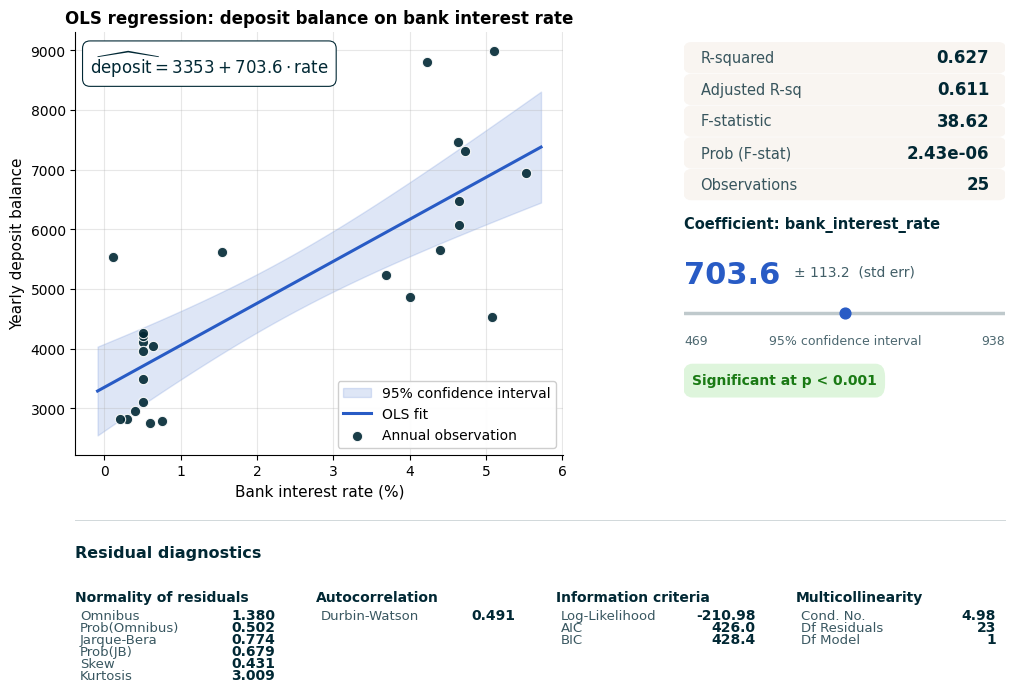


Saved charts_eda_fis/macroeconomic_influence_regression_result_ols.png


In [23]:
# Build the figure: 2 rows × 2 cols
#   top-left  = scatter + fit
#   top-right = metrics + coefficient detail
#   bottom    = diagnostics strip (spans both)

fig = plt.figure(figsize=(12, 8.5))
gs = GridSpec(
    2, 2,
    width_ratios=[1.9, 1.25],
    height_ratios=[3.0, 1.0],
    wspace=0.30, hspace=0.32,
    figure=fig,
)

# ============ TOP-LEFT: scatter + fit ============
ax = fig.add_subplot(gs[0, 0])
ax.fill_between(x_grid, pred["mean_ci_lower"], pred["mean_ci_upper"],
                color=FIS["blue"], alpha=0.15, label="95% confidence interval")
ax.plot(x_grid, pred["mean"], color=FIS["blue"], linewidth=2.2, label="OLS fit")
ax.scatter(df["bank_interest_rate"], df["yearly_deposit_balance"],
           color=FIS["dark_green"], s=55, zorder=3, alpha=0.9,
           edgecolor="white", linewidth=0.8, label="Annual observation")

beta0, beta1 = model.params["const"], model.params["bank_interest_rate"]
eqn = f"$\\widehat{{\\mathrm{{deposit}}}} = {beta0:.0f} + {beta1:.1f} \\cdot \\mathrm{{rate}}$"
ax.text(0.03, 0.96, eqn, transform=ax.transAxes, fontsize=12,
        va="top", ha="left", color=FIS["dark_green"],
        bbox=dict(boxstyle="round,pad=0.45",
                  facecolor="white", edgecolor=FIS["dark_green"], linewidth=0.8))

ax.set_xlabel("Bank interest rate (%)", fontsize=11)
ax.set_ylabel("Yearly deposit balance", fontsize=11)
ax.set_title("OLS regression: deposit balance on bank interest rate")
ax.legend(loc="lower right", frameon=True, framealpha=0.95)

# ============ TOP-RIGHT: metrics + coefficient detail ============
ax2 = fig.add_subplot(gs[0, 1])
ax2.axis("off")

metrics = [
    ("R-squared",     f"{model.rsquared:.3f}"),
    ("Adjusted R-sq", f"{model.rsquared_adj:.3f}"),
    ("F-statistic",   f"{model.fvalue:.2f}"),
    ("Prob (F-stat)", f"{model.f_pvalue:.2e}"),
    ("Observations",  f"{int(model.nobs)}"),
]
y_start, row_h = 0.97, 0.075
for i, (label, value) in enumerate(metrics):
    yp = y_start - i * row_h
    ax2.add_patch(mpatches.FancyBboxPatch(
        (0.0, yp - row_h * 0.85), 1.0, row_h * 0.85,
        boxstyle="round,pad=0.005,rounding_size=0.025",
        transform=ax2.transAxes, facecolor=FIS["panel_bg"],
        edgecolor="none", zorder=0))
    ax2.text(0.05, yp - row_h * 0.42, label, transform=ax2.transAxes,
             fontsize=10.5, color=FIS["dark_green"], alpha=0.78, va="center")
    ax2.text(0.95, yp - row_h * 0.42, value, transform=ax2.transAxes,
             fontsize=12, weight="bold", color=FIS["dark_green"],
             va="center", ha="right")

coef_top = y_start - len(metrics) * row_h - 0.06
ax2.text(0.0, coef_top, "Coefficient: bank_interest_rate",
         transform=ax2.transAxes, fontsize=10.5, weight="bold",
         color=FIS["dark_green"])

ci_low  = model.conf_int().loc["bank_interest_rate", 0]
ci_high = model.conf_int().loc["bank_interest_rate", 1]
se      = model.bse["bank_interest_rate"]

ax2.text(0.0, coef_top - 0.075, f"{beta1:.1f}",
         transform=ax2.transAxes, fontsize=22, weight="bold",
         color=FIS["blue"], va="top")
ax2.text(0.34, coef_top - 0.085, f"± {se:.1f}  (std err)",
         transform=ax2.transAxes, fontsize=10,
         color=FIS["dark_green"], alpha=0.75, va="top")

ci_y = coef_top - 0.20
ax2.plot([0.0, 1.0], [ci_y, ci_y], transform=ax2.transAxes,
         color=FIS["dark_green"], alpha=0.25, linewidth=2.5,
         solid_capstyle="round")
mid_frac = (beta1 - ci_low) / (ci_high - ci_low)
ax2.scatter([mid_frac], [ci_y], transform=ax2.transAxes,
            s=60, color=FIS["blue"], zorder=3)
ax2.text(0.0, ci_y - 0.05, f"{ci_low:.0f}", transform=ax2.transAxes,
         fontsize=9, color=FIS["dark_green"], alpha=0.7, ha="left", va="top")
ax2.text(1.0, ci_y - 0.05, f"{ci_high:.0f}", transform=ax2.transAxes,
         fontsize=9, color=FIS["dark_green"], alpha=0.7, ha="right", va="top")
ax2.text(0.5, ci_y - 0.05, "95% confidence interval",
         transform=ax2.transAxes, fontsize=9,
         color=FIS["dark_green"], alpha=0.7, ha="center", va="top")

sig_y = ci_y - 0.16
ax2.add_patch(mpatches.FancyBboxPatch(
    (0.0, sig_y - 0.035), 0.62, 0.07,
    boxstyle="round,pad=0.005,rounding_size=0.03",
    transform=ax2.transAxes, facecolor=FIS["green"],
    edgecolor="none", alpha=0.18))
ax2.text(0.31, sig_y, "Significant at p < 0.001",
         transform=ax2.transAxes, fontsize=10, weight="bold",
         color="#1a7a14", ha="center", va="center")

# ============ BOTTOM: diagnostics strip ============
ax3 = fig.add_subplot(gs[1, :])
ax3.axis("off")

ax3.text(0.0, 1.0, "Residual diagnostics",
         transform=ax3.transAxes, fontsize=11.5, weight="bold",
         color=FIS["dark_green"], va="top")

groups = [
    {
        "title": "Normality of residuals",
        "rows": [
            ("Omnibus",       f"{omni_stat:.3f}"),
            ("Prob(Omnibus)", f"{omni_p:.3f}"),
            ("Jarque-Bera",   f"{jb_stat:.3f}"),
            ("Prob(JB)",      f"{jb_p:.3f}"),
            ("Skew",          f"{jb_skew:.3f}"),
            ("Kurtosis",      f"{jb_kurt:.3f}"),
        ],
    },
    {
        "title": "Autocorrelation",
        "rows": [
            ("Durbin-Watson", f"{dw:.3f}"),
        ],
    },
    {
        "title": "Information criteria",
        "rows": [
            ("Log-Likelihood", f"{model.llf:.2f}"),
            ("AIC",            f"{model.aic:.1f}"),
            ("BIC",            f"{model.bic:.1f}"),
        ],
    },
    {
        "title": "Multicollinearity",
        "rows": [
            ("Cond. No.",    f"{cond_no:.2f}"),
            ("Df Residuals", f"{int(model.df_resid)}"),
            ("Df Model",     f"{int(model.df_model)}"),
        ],
    },
]

col_w = 0.225
col_gap = (1.0 - 4 * col_w) / 3
x_starts = [i * (col_w + col_gap) for i in range(4)]

for xs, group in zip(x_starts, groups):
    ax3.text(xs, 0.68, group["title"],
             transform=ax3.transAxes, fontsize=10, weight="bold",
             color=FIS["dark_green"], va="top")
    rows_top = 0.50
    row_height = 0.085
    for r_i, (label, value) in enumerate(group["rows"]):
        ry = rows_top - r_i * row_height
        ax3.text(xs + 0.005, ry, label,
                 transform=ax3.transAxes, fontsize=9.5,
                 color=FIS["dark_green"], alpha=0.78,
                 ha="left", va="center")
        value_x = xs + col_w - 0.01
        ax3.text(value_x, ry, value,
                 transform=ax3.transAxes, fontsize=10,
                 weight="bold", color=FIS["dark_green"],
                 ha="right", va="center")

# Separator line above the diagnostics strip
ax3.plot([0.0, 1.0], [1.18, 1.18],
         transform=ax3.transAxes,
         color=FIS["dark_green"], alpha=0.18, linewidth=0.7,
         clip_on=False)

# Save
out_path = f"{OUT_DIR_BANKING}/macroeconomic_influence_regression_result_ols.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"\nSaved {out_path}")


---
## 5. Summary

**Total output: 21 charts**

`charts_eda_fis/` (12 files):
- `banking_infrastructure_trends_*` (3 — branches, banks, ATM share)
- `customer_behaviour_indicators_*` (2 — total switches, composition)
- `interest_rates_and_deposit_behaviour_*` (2 — deposit balance, scatter)
- `shift_from_physical_to_digital_banking_*` (2 — branches vs faster payments, vs cash)
- `macroeconomic_influence_*` (2 — deposit + rate dual axis, OLS regression)
- `correlation_matrix_analysis_correlation_banking_payment.png`

`charts_payments_eda_fis/` (9 files):
- `overall_payment_behaviour_trends_*`
- `payment_method_composition_*`
- `growth_rates_and_inflection_points_*` (2)
- `cash_usage_vs_contactless_payments_*`
- `contactless_limit_changes_and_payment_behaviour_*`
- `digital_payment_adoption_and_card_fraud_*` (3)


---
# Part B — Modelling and forecasting pipeline

Section 6 (Modelling & Forecasting) implemented end-to-end in the notebook.
Each subsection inlines one logical module's worth of code, then exposes it
to subsequent sections under a familiar namespace (`models.fit_curve(...)`,
`A.get(...)`, etc.) so the modelling code stays readable.

| Section | What it provides |
|---|---|
| 5 | Functional forms (Gompertz, Bass, ARDL, damped Holt) + fit helpers |
| 6 | Assumptions register (parameters not estimated from data) |
| 7 | Per-variable forecasters + `run_all` orchestrator |
| 8 | Sensitivity analysis (tornado + Monte Carlo) |
| 9 | FIS-branded forecast plotting (18 per-variable charts + mix + tornado) |

Each section ends with a `SimpleNamespace` alias so downstream code reads
exactly like the original modular version.

---
## 5. Models

Interpretable, parameter-light functional forms — chosen because the data
horizons are short (n=10-25 per variable after cleaning), so
heavily-parameterised models would overfit transient noise.

In [24]:
"""
models.py
=========
Forecasting model implementations used in Section 6.

Models are deliberately interpretable and parameter-light so each result is
defensible to a non-technical industry audience. All models accept arrays of
years and return arrays of the same shape.

Implementations
---------------
1. floored_exponential_decline – cash, branches, banks
2. gompertz                    – contactless adoption (S-curve)
3. logistic                    – ATM-share, fraud composition (substitution)
4. fisher_pry                  – traditional vs neobank substitution
5. bass_diffusion              – mobile wallets, wearables (analogy-based)
6. damped_holt                 – debit/credit card volumes, ATM totals, fraud total
7. dynamic_regression          – deposit balance vs interest rate (ARDL-style)
"""

from dataclasses import dataclass
from typing import Callable, Sequence

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from statsmodels.tsa.holtwinters import ExponentialSmoothing


# ----------------------------------------------------------------------------
# Functional forms
# ----------------------------------------------------------------------------

def floored_exponential_decline(t: np.ndarray, floor: float, y0: float, k: float) -> np.ndarray:
    r"""
    y(t) = floor + (y0 - floor) * exp(-k * t)

    `t` is years since series start (0, 1, 2, ...). `floor` is an asymptotic
    minimum that the series approaches but never crosses; `y0` is the value
    at t=0; `k` is the decay rate.
    """
    return floor + (y0 - floor) * np.exp(-k * t)


def gompertz(t: np.ndarray, K: float, b: float, c: float) -> np.ndarray:
    r"""
    Gompertz S-curve: y(t) = K * exp(-b * exp(-c * t))

    Asymmetric adoption curve (slow start, fast middle, gradual approach to K).
    Tends to fit financial-services adoption better than the symmetric logistic.
    """
    return K * np.exp(-b * np.exp(-c * t))


def logistic(t: np.ndarray, K: float, t0: float, k: float) -> np.ndarray:
    r"""
    Symmetric logistic curve: y(t) = K / (1 + exp(-k * (t - t0)))
    """
    return K / (1.0 + np.exp(-k * (t - t0)))


def fisher_pry(t: np.ndarray, t_mid: float, k: float) -> np.ndarray:
    r"""
    Fisher-Pry market substitution share: f(t) = 1 / (1 + exp(-k * (t - t_mid)))

    Used for two-technology substitution (e.g. neobanks displacing
    traditional incumbents). Always bounded in [0,1].
    """
    return 1.0 / (1.0 + np.exp(-k * (t - t_mid)))


def bass_diffusion_cumulative(t: np.ndarray, m: float, p: float, q: float) -> np.ndarray:
    r"""
    Bass cumulative-adoption fraction:
        F(t) = m * (1 - exp(-(p+q)*t)) / (1 + (q/p) * exp(-(p+q)*t))

    `m`: market potential (asymptotic adopters)
    `p`: coefficient of innovation
    `q`: coefficient of imitation
    """
    s = (p + q) * t
    return m * (1.0 - np.exp(-s)) / (1.0 + (q / p) * np.exp(-s))


# ----------------------------------------------------------------------------
# Curve-fit helper
# ----------------------------------------------------------------------------

@dataclass
class CurveFitResult:
    name: str
    params: np.ndarray
    cov: np.ndarray
    fitted_y: np.ndarray
    residuals: np.ndarray
    rmse: float
    mape: float
    r2: float

    def predict(self, x_future: np.ndarray, model_fn: Callable) -> np.ndarray:
        return model_fn(x_future, *self.params)


def fit_curve(
    model_fn: Callable,
    x: np.ndarray,
    y: np.ndarray,
    p0: Sequence[float],
    bounds: tuple = (-np.inf, np.inf),
    name: str = "",
    maxfev: int = 20000,
) -> CurveFitResult:
    """Wrap `scipy.optimize.curve_fit` with diagnostics."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    params, cov = curve_fit(model_fn, x, y, p0=p0, bounds=bounds, maxfev=maxfev)
    fitted = model_fn(x, *params)
    resid = y - fitted
    rmse = float(np.sqrt(np.mean(resid ** 2)))
    # MAPE only where |y|>0
    mask = np.abs(y) > 1e-9
    mape = float(np.mean(np.abs(resid[mask] / y[mask]))) if mask.any() else float("nan")
    ss_res = float(np.sum(resid ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    return CurveFitResult(name, params, cov, fitted, resid, rmse, mape, r2)


# ----------------------------------------------------------------------------
# Damped Holt (state-space)
# ----------------------------------------------------------------------------

@dataclass
class HoltResult:
    name: str
    fitted: np.ndarray
    residuals: np.ndarray
    rmse: float
    aic: float
    forecast: np.ndarray          # point forecast
    lo: np.ndarray                # lower 80% PI
    hi: np.ndarray                # upper 80% PI
    smoothing_level: float
    smoothing_trend: float
    damping_trend: float


def fit_damped_holt(
    y: np.ndarray,
    horizon: int,
    name: str = "",
    pi_alpha: float = 0.20,           # 80% prediction interval
) -> HoltResult:
    """
    Fit a damped additive-trend Holt model.

    Damping is essential here because most of these series are saturating
    and an undamped linear trend would project unrealistically far out.
    """
    y = np.asarray(y, dtype=float)
    model = ExponentialSmoothing(
        y, trend="add", damped_trend=True, seasonal=None,
        initialization_method="estimated",
    )
    fit = model.fit(optimized=True)
    fitted = fit.fittedvalues
    resid = y - fitted
    rmse = float(np.sqrt(np.mean(resid ** 2)))

    # Bootstrap-style PI from residual variance (Hyndman & Athanasopoulos, ch. 8)
    point = np.asarray(fit.forecast(horizon))
    sigma = float(np.std(resid, ddof=1))
    z = 1.282  # 80% PI
    se = sigma * np.sqrt(np.arange(1, horizon + 1))
    lo = point - z * se
    hi = point + z * se

    return HoltResult(
        name=name,
        fitted=np.asarray(fitted),
        residuals=resid,
        rmse=rmse,
        aic=float(fit.aic),
        forecast=point,
        lo=lo,
        hi=hi,
        smoothing_level=float(fit.params.get("smoothing_level", float("nan"))),
        smoothing_trend=float(fit.params.get("smoothing_trend", float("nan"))),
        damping_trend=float(fit.params.get("damping_trend", float("nan"))),
    )


# ----------------------------------------------------------------------------
# Dynamic regression (deposit balance ~ interest rate)
# ----------------------------------------------------------------------------

@dataclass
class DynRegResult:
    name: str
    coef: dict
    rmse: float
    r2: float
    fitted: np.ndarray
    forecast_by_scenario: dict[str, np.ndarray]


def fit_dynamic_regression(
    y: np.ndarray,
    x: np.ndarray,
    x_future_by_scenario: dict[str, np.ndarray],
    name: str = "",
    include_lag_y: bool = True,
) -> DynRegResult:
    """
    ARDL(1,0)-style: y_t = c + phi*y_{t-1} + beta*x_t + e_t

    Returns coefficients, in-sample diagnostics, and conditional forecasts
    under each named scenario for the exogenous variable x.
    """
    import statsmodels.api as sm

    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)

    if include_lag_y:
        y_lag = np.r_[np.nan, y[:-1]]
        df = pd.DataFrame({"y": y, "y_lag": y_lag, "x": x}).dropna()
        X = sm.add_constant(df[["y_lag", "x"]])
        Y = df["y"]
    else:
        df = pd.DataFrame({"y": y, "x": x}).dropna()
        X = sm.add_constant(df[["x"]])
        Y = df["y"]

    fit = sm.OLS(Y, X).fit()
    fitted = np.asarray(fit.fittedvalues)
    resid = np.asarray(fit.resid)
    rmse = float(np.sqrt(np.mean(resid ** 2)))
    r2 = float(fit.rsquared)
    coef = {k: float(v) for k, v in fit.params.items()}

    forecasts = {}
    for scen, x_fut in x_future_by_scenario.items():
        fc = []
        y_prev = float(y[-1])
        for x_val in x_fut:
            if include_lag_y:
                y_hat = coef["const"] + coef["y_lag"] * y_prev + coef["x"] * x_val
            else:
                y_hat = coef["const"] + coef["x"] * x_val
            fc.append(y_hat)
            y_prev = y_hat
        forecasts[scen] = np.asarray(fc)

    return DynRegResult(
        name=name, coef=coef, rmse=rmse, r2=r2,
        fitted=fitted, forecast_by_scenario=forecasts,
    )


__all__ = [
    "floored_exponential_decline",
    "gompertz",
    "logistic",
    "fisher_pry",
    "bass_diffusion_cumulative",
    "fit_curve",
    "fit_damped_holt",
    "fit_dynamic_regression",
    "CurveFitResult",
    "HoltResult",
    "DynRegResult",
]


**Expose under the `models` namespace** so downstream code can call `models.fit_curve(...)` exactly as the original modular version did:

In [25]:
from types import SimpleNamespace

models = SimpleNamespace(
    floored_exponential_decline=floored_exponential_decline,
    gompertz=gompertz,
    logistic=logistic,
    fisher_pry=fisher_pry,
    bass_diffusion_cumulative=bass_diffusion_cumulative,
    fit_curve=fit_curve,
    fit_damped_holt=fit_damped_holt,
    fit_dynamic_regression=fit_dynamic_regression,
    CurveFitResult=CurveFitResult,
    HoltResult=HoltResult,
    DynRegResult=DynRegResult,
)
print("models namespace ready")


models namespace ready


---
## 6. Assumptions register

Every parameter that is *not* estimated from the data — floors, ceilings,
2024 anchors, scenario rate paths — lives here in one place. Each entry
has `low` / `base` / `high` values plus a rationale.

Forecasters in section 7 query this register via `A.get(name, level)`.

In [26]:
"""
assumptions.py
==============
Central register of every parameter that is *not* estimated from the data.
Each entry has:
    - a short ID
    - a description
    - a base / low / high value
    - a source or rationale

The objective is full transparency for the FIS industry partner: anything
that materially shapes the forecast but did not come from the cleaned UK
data should be visible here, in one place.

The values shipped here are the project team's central judgements as of
the build date and are easy to change in one place.
"""

import pandas as pd

# ----------------------------------------------------------------------------
# Forecast horizon
# ----------------------------------------------------------------------------

FORECAST_END_YEAR = 2034   # ten years from the latest payment-method observation
HISTORY_LATEST_YEAR_PAYMENTS = 2024
HISTORY_LATEST_YEAR_INFRA = 2025

# ----------------------------------------------------------------------------
# Parameter assumptions
# ----------------------------------------------------------------------------

ASSUMPTIONS = [
    # ---------- Cash --------------------------------------------------------
    {
        "id": "CASH_FLOOR_BN",
        "description": "Long-run irreducible floor on UK cash transaction volume "
                       "(billions of transactions per year).",
        "low": 1.0, "base": 2.0, "high": 3.0,
        "rationale": "Cash retains a structural minimum for the financially "
                     "excluded, certain micro-payments, gifting, and contingency. "
                     "UK Finance and FCA continue to highlight cash-access "
                     "obligations. Range chosen to span 'cashless economy' "
                     "(1bn) to 'persistent niche' (3bn) outcomes."
    },

    # ---------- Bank branches ----------------------------------------------
    {
        "id": "BRANCH_FLOOR",
        "description": "Long-run minimum number of UK retail bank branches.",
        "low": 1500, "base": 2500, "high": 3500,
        "rationale": "Minimum-viable-network argument: branches won't hit zero "
                     "given regulatory and demographic constraints (vulnerable "
                     "customers, business banking, cash deposits). The lower "
                     "bound assumes aggressive shared-banking-hub adoption; "
                     "the upper bound assumes consolidation slows."
    },

    # ---------- Banks -------------------------------------------------------
    {
        "id": "BANKS_FLOOR",
        "description": "Long-run minimum number of UK banks.",
        "low": 220, "base": 260, "high": 290,
        "rationale": "Reflects continued consolidation amongst building "
                     "societies and specialist lenders, partially offset by "
                     "new entrants (challenger and neobanks)."
    },

    # ---------- Contactless ceiling ----------------------------------------
    {
        "id": "CONTACTLESS_SHARE_CEILING",
        "description": "Maximum share of card transactions that are contactless. "
                       "Lever: 2026 regulatory cap removal raises ceiling.",
        "low": 0.75, "base": 0.85, "high": 0.95,
        "rationale": "Some card spend will remain non-contactless: high-value "
                     "purchases, online card-not-present, mail-order, ATM "
                     "withdrawals on card. The 2026 cap removal pushes the "
                     "high scenario toward near-total displacement."
    },

    # ---------- Faster payments ceiling ------------------------------------
    {
        "id": "FASTER_PAYMENTS_CEILING_BN",
        "description": "Long-run ceiling on faster payments + remote banking volume "
                       "(billions of transactions per year).",
        "low": 8.0, "base": 12.0, "high": 18.0,
        "rationale": "Open-banking and account-to-account payment growth, plus "
                     "potential displacement of card payments by Pay-by-Bank. "
                     "Range broadens because of regulatory and technology uncertainty."
    },

    # ---------- Mobile wallet adoption -------------------------------------
    {
        "id": "MOBILE_WALLET_2024_ANCHOR",
        "description": "Estimated share of UK adults using a mobile wallet in 2024.",
        "low": 0.55, "base": 0.60, "high": 0.65,
        "rationale": "UK Finance press releases indicate that more than half of "
                     "UK adults now use mobile wallets (e.g. Apple Pay, Google "
                     "Pay). Treated as an external anchor, not estimated."
    },
    {
        "id": "MOBILE_WALLET_CEILING",
        "description": "Long-run share of UK adults using mobile wallets.",
        "low": 0.75, "base": 0.85, "high": 0.95,
        "rationale": "Bounded by digital exclusion (older cohorts, accessibility) "
                     "and personal preference. Ceiling unlikely to reach 100%."
    },

    # ---------- Wearables --------------------------------------------------
    {
        "id": "WEARABLES_2024_ANCHOR_SHARE_OF_CONTACTLESS",
        "description": "Estimated 2024 share of contactless transactions made via "
                       "a wearable device (smartwatch, ring, etc.).",
        "low": 0.03, "base": 0.05, "high": 0.08,
        "rationale": "Limited public data. Triangulated from device-shipment "
                     "numbers (Apple Watch, Fitbit Pay-enabled wearables) and "
                     "industry estimates of active payment-enabled use."
    },
    {
        "id": "WEARABLES_CEILING_SHARE_OF_CONTACTLESS",
        "description": "Long-run share of contactless transactions made via a wearable.",
        "low": 0.10, "base": 0.20, "high": 0.30,
        "rationale": "Constrained by device penetration; smartphone-based wallets "
                     "are likely to dominate, with wearables a meaningful "
                     "complement rather than substitute."
    },
    {
        "id": "WEARABLES_LAG_YEARS",
        "description": "Years of adoption lag of wearables behind mobile wallets.",
        "low": 4, "base": 6, "high": 8,
        "rationale": "Wearables lag the smartphone-payment trajectory because "
                     "device installed-base growth is slower."
    },

    # ---------- Crypto / digital currency ----------------------------------
    {
        "id": "CRYPTO_2024_PAYMENT_VOLUME_SHARE",
        "description": "Estimated 2024 share of UK consumer payment volume "
                       "settled in crypto/stablecoins.",
        "low": 0.0005, "base": 0.001, "high": 0.003,
        "rationale": "Negligible at present. Bank of England data on crypto "
                     "use in payments suggests a very small fraction. Range "
                     "treats this as essentially zero with three orders of "
                     "uncertainty."
    },
    {
        "id": "CRYPTO_2034_SHARE_NICHE",
        "description": "2034 share under 'niche stable' scenario.",
        "low": None, "base": 0.003, "high": None,
        "rationale": "Crypto remains an investment asset and niche payment "
                     "rail. Limited consumer payments uptake. No CBDC."
    },
    {
        "id": "CRYPTO_2034_SHARE_REGULATED_MAINSTREAM",
        "description": "2034 share under 'regulated mainstream' scenario.",
        "low": None, "base": 0.02, "high": None,
        "rationale": "Stablecoin rails enter consumer payments; tokenised "
                     "deposits become commonplace. Material niche but not core."
    },
    {
        "id": "CRYPTO_2034_SHARE_CBDC_LED",
        "description": "2034 share under 'CBDC-led displacement' scenario.",
        "low": None, "base": 0.05, "high": None,
        "rationale": "Digital pound launches and is adopted alongside or in "
                     "place of card payments for small-value transactions. "
                     "Most aggressive scenario; depends on policy choices "
                     "outside the model."
    },

    # ---------- Neobank market share ---------------------------------------
    {
        "id": "NEOBANK_2024_PCA_SHARE",
        "description": "Estimated 2024 share of UK personal current accounts "
                       "held with a neobank as primary account.",
        "low": 0.20, "base": 0.25, "high": 0.30,
        "rationale": "FCA financial-lives surveys, Statista and CMA "
                     "competition reviews place this in the low-to-mid 20s. "
                     "Distinguished from secondary-account or app-only use, "
                     "which is materially higher."
    },
    {
        "id": "NEOBANK_CEILING_PCA_SHARE",
        "description": "Long-run ceiling on neobank share of UK primary "
                       "personal current accounts.",
        "low": 0.35, "base": 0.50, "high": 0.65,
        "rationale": "Incumbents retain advantages in mortgages, lending and "
                     "long-tenured customers; full neobank dominance is "
                     "unlikely within the horizon. Ceiling reflects the "
                     "portion of customers willing and able to switch primary "
                     "banking relationship."
    },

    # ---------- Interest rate scenarios ------------------------------------
    {
        "id": "BANK_RATE_PATH_LOW",
        "description": "Bank Rate path in low/cutting scenario (annual %).",
        "low": None, "base": 1.5, "high": None,
        "rationale": "Disinflation is decisive; MPC eases below neutral by 2027 "
                     "and remains accommodative."
    },
    {
        "id": "BANK_RATE_PATH_BASE",
        "description": "Bank Rate path in base/normalising scenario (annual %).",
        "low": None, "base": 3.0, "high": None,
        "rationale": "MPC's central path: inflation returns to target, rates "
                     "settle around long-run neutral."
    },
    {
        "id": "BANK_RATE_PATH_HIGH",
        "description": "Bank Rate path in high/sticky-inflation scenario (annual %).",
        "low": None, "base": 4.5, "high": None,
        "rationale": "Inflation persistence requires elevated rates for longer; "
                     "supply-side shocks recur."
    },
]


def assumptions_dataframe() -> pd.DataFrame:
    """Return the assumptions register as a pandas DataFrame."""
    return pd.DataFrame(ASSUMPTIONS, columns=[
        "id", "description", "low", "base", "high", "rationale"
    ])


# ----------------------------------------------------------------------------
# Convenience getters
# ----------------------------------------------------------------------------

def get(name: str, level: str = "base") -> float:
    for a in ASSUMPTIONS:
        if a["id"] == name:
            v = a[level]
            if v is None:
                raise KeyError(f"Assumption {name} has no value at level {level}")
            return v
    raise KeyError(f"Assumption {name} not in register")


__all__ = [
    "FORECAST_END_YEAR",
    "HISTORY_LATEST_YEAR_PAYMENTS",
    "HISTORY_LATEST_YEAR_INFRA",
    "ASSUMPTIONS",
    "assumptions_dataframe",
    "get",
]


In [27]:
# Expose under the `A` namespace
A = SimpleNamespace(
    FORECAST_END_YEAR=FORECAST_END_YEAR,
    HISTORY_LATEST_YEAR_PAYMENTS=HISTORY_LATEST_YEAR_PAYMENTS,
    HISTORY_LATEST_YEAR_INFRA=HISTORY_LATEST_YEAR_INFRA,
    ASSUMPTIONS=ASSUMPTIONS,
    assumptions_dataframe=assumptions_dataframe,
    get=get,
)
print(f"{len(A.ASSUMPTIONS)} assumptions registered, horizon -> {A.FORECAST_END_YEAR}")
A.assumptions_dataframe()[["id", "low", "base", "high", "description"]]


19 assumptions registered, horizon -> 2034


,id,low,base,high,description
0,CASH_FLOOR_BN,1.0000,2.000,3.000,Long-run irreducible floor on UK cash transact...
1,BRANCH_FLOOR,1500.0000,2500.000,3500.000,Long-run minimum number of UK retail bank bran...
2,BANKS_FLOOR,220.0000,260.000,290.000,Long-run minimum number of UK banks.
3,CONTACTLESS_SHARE_CEILING,0.7500,0.850,0.950,Maximum share of card transactions that are co...
4,FASTER_PAYMENTS_CEILING_BN,8.0000,12.000,18.000,Long-run ceiling on faster payments + remote b...
5,MOBILE_WALLET_2024_ANCHOR,0.5500,0.600,0.650,Estimated share of UK adults using a mobile wa...
6,MOBILE_WALLET_CEILING,0.7500,0.850,0.950,Long-run share of UK adults using mobile wallets.
7,WEARABLES_2024_ANCHOR_SHARE_OF_CONTACTLESS,0.0300,0.050,0.080,Estimated 2024 share of contactless transactio...
8,WEARABLES_CEILING_SHARE_OF_CONTACTLESS,0.1000,0.200,0.300,Long-run share of contactless transactions mad...
9,WEARABLES_LAG_YEARS,4.0000,6.000,8.000,Years of adoption lag of wearables behind mobi...


---
## 7. Forecasts

Per-variable forecasters that each return a long-format dataframe with
`variable | year | scenario | value | lo80 | hi80 | model | units | note`.
The `run_all` function orchestrates them all into a single `master` table.

**Variable → model map:**

| Length | Variables | Model |
|---|---|---|
| Long (n ≥ 25) | branches, banks, ATMs, free-ATM share, deposits | floored exp / Holt / logistic / ARDL |
| Borderline (10 ≤ n < 20) | cash, debit, credit, faster payments, contactless share, total fraud, CNP share | floored exp / Holt / Gompertz / logistic (COVID year dropped) |
| Not in dataset | mobile wallets, wearables, crypto, neobank PCA | Bass / Fisher-Pry / scenario paths |

In [28]:
# Expose data_prep functions (already defined in Part A section 1) as a namespace
data_prep = SimpleNamespace(
    load_all=load_all,
    build_payments_features=build_payments_features,
    build_atm_features=build_atm_features,
    build_fraud_features=build_fraud_features,
    drop_covid_year=drop_covid_year,
    covid_pandemic_dummy=covid_pandemic_dummy,
)


In [29]:
"""
forecasts.py
============
Generates 10-year forecasts (to 2034) for every variable in scope, applying
the model selected for that variable's data shape and length. Returns a long
dataframe suitable for charting and table export.

Variable-to-model map (final, post data audit)
----------------------------------------------
Long history (n >= 25)
    * bank_branches               : floored exponential decline
    * number_of_banks_uk          : floored exponential decline
    * total_atm_count             : damped Holt
    * free_atm_share              : logistic
    * yearly_deposit_balance      : dynamic regression on Bank Rate

Borderline (10 <= n < 20) – simple models, drop COVID year
    * cash                        : floored exponential decline
    * debit_card                  : damped Holt
    * credit_card                 : damped Holt
    * faster_payments_remote_b.   : Gompertz on absolute volume
    * contactless_share_of_cards  : Gompertz, three-ceiling scenarios
    * total_card_fraud            : damped Holt
    * cnp_share_of_total          : logistic substitution

Too short (n < 10) – scenario or qualitative only
    * cass total_switches         : observed-range bands

Not in dataset – scenario by analogy to contactless trajectory
    * mobile_wallet_adult_share   : Bass diffusion
    * wearables_share_contactless : Bass diffusion (lagged)
    * crypto_share_of_payments    : three labelled paths
    * neobank_pca_share           : Fisher–Pry substitution
"""

import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------------------
# Helpers
# ----------------------------------------------------------------------------

def _years_from(start: int, end: int) -> np.ndarray:
    return np.arange(start, end + 1)


def _make_record(variable: str, year: int, scenario: str,
                 point: float, lo: float | None = None, hi: float | None = None,
                 model: str = "", units: str = "", note: str = "") -> dict:
    return {
        "variable": variable,
        "year": int(year),
        "scenario": scenario,
        "value": float(point),
        "lo80": float(lo) if lo is not None else np.nan,
        "hi80": float(hi) if hi is not None else np.nan,
        "model": model,
        "units": units,
        "note": note,
    }


# ----------------------------------------------------------------------------
# Forecasters
# ----------------------------------------------------------------------------

def forecast_bank_branches(infra: pd.DataFrame, end_year: int) -> pd.DataFrame:
    df = infra.dropna(subset=["bank_branches_count"]).copy().sort_values("year")
    t = (df["year"].values - df["year"].min()).astype(float)
    y = df["bank_branches_count"].values.astype(float)
    fc_years = np.arange(int(df["year"].max()) + 1, end_year + 1)
    last_actual_year = int(df["year"].max())
    last_actual_value = float(y[-1])
    rows = []

    for level, scen in [("low", "Low"), ("base", "Base"), ("high", "High")]:
        floor = A.get("BRANCH_FLOOR", level)
        # Fit with floor fixed
        def model_fn(t_, y0, k, _floor=floor):
            return models.floored_exponential_decline(t_, _floor, y0, k)

        # Robust bounds: y0 near observed first value, k positive
        res = models.fit_curve(
            model_fn, t, y, p0=[y[0], 0.05],
            bounds=([y[0] * 0.5, 1e-4], [y[0] * 1.5, 0.5]),
            name=f"branches_{level}",
        )
        # Anchor forecast to latest actual using fitted decay rate
        k_fit = res.params[1]
        y_future = floor + (last_actual_value - floor) * np.exp(
            -k_fit * (fc_years - last_actual_year)
        )

        # Emit historical fit only once (base case) to avoid plot clutter
        if level == "base":
            for yr, val in zip(df["year"].values, res.fitted_y):
                rows.append(_make_record("bank_branches", yr, "Historical fit",
                                         val, model="floored exp decline",
                                         units="count"))
        for yr, val in zip(fc_years, y_future):
            rows.append(_make_record("bank_branches", yr, scen, val,
                                     model="floored exp decline (anchored)",
                                     units="count",
                                     note=f"floor={floor}, k={k_fit:.3f}"))
    # also tag actuals
    for yr, val in zip(df["year"].values, y):
        rows.append(_make_record("bank_branches", yr, "Actual", val,
                                 units="count"))
    return pd.DataFrame(rows)


def forecast_number_of_banks(infra: pd.DataFrame, end_year: int) -> pd.DataFrame:
    df = infra.dropna(subset=["number_of_banks_uk"]).copy().sort_values("year")
    t = (df["year"].values - df["year"].min()).astype(float)
    y = df["number_of_banks_uk"].values.astype(float)
    fc_years = np.arange(int(df["year"].max()) + 1, end_year + 1)
    last_actual_year = int(df["year"].max())
    last_actual_value = float(y[-1])
    rows = []
    for level, scen in [("low", "Low"), ("base", "Base"), ("high", "High")]:
        floor = A.get("BANKS_FLOOR", level)
        def model_fn(t_, y0, k, _floor=floor):
            return models.floored_exponential_decline(t_, _floor, y0, k)
        res = models.fit_curve(
            model_fn, t, y, p0=[y[0], 0.02],
            bounds=([y[0] * 0.7, 1e-5], [y[0] * 1.3, 0.3]),
            name=f"banks_{level}",
        )
        # Anchor forecast to latest actual using fitted decay rate
        k_fit = res.params[1]
        y_future = floor + (last_actual_value - floor) * np.exp(
            -k_fit * (fc_years - last_actual_year)
        )
        if level == "base":
            for yr, val in zip(df["year"].values, res.fitted_y):
                rows.append(_make_record("number_of_banks_uk", yr, "Historical fit",
                                         val, model="floored exp decline", units="count"))
        for yr, val in zip(fc_years, y_future):
            rows.append(_make_record("number_of_banks_uk", yr, scen, val,
                                     model="floored exp decline (anchored)",
                                     units="count", note=f"floor={floor}, k={k_fit:.3f}"))
    for yr, val in zip(df["year"].values, y):
        rows.append(_make_record("number_of_banks_uk", yr, "Actual", val,
                                 units="count"))
    return pd.DataFrame(rows)


def forecast_total_atms(infra: pd.DataFrame, end_year: int) -> pd.DataFrame:
    df = infra.dropna(subset=["total_atm_count"]).copy().sort_values("year")
    y = df["total_atm_count"].values.astype(float)
    fc_years = np.arange(int(df["year"].max()) + 1, end_year + 1)
    res = models.fit_damped_holt(y, horizon=len(fc_years), name="total_atms")
    rows = []
    for yr, val in zip(df["year"].values, res.fitted):
        rows.append(_make_record("total_atm_count", yr, "Historical fit", val,
                                 model="damped Holt", units="count"))
    for yr, val, lo, hi in zip(fc_years, res.forecast, res.lo, res.hi):
        rows.append(_make_record("total_atm_count", yr, "Base", val, lo, hi,
                                 model="damped Holt", units="count"))
    for yr, val in zip(df["year"].values, y):
        rows.append(_make_record("total_atm_count", yr, "Actual", val,
                                 units="count"))
    return pd.DataFrame(rows)


def forecast_free_atm_share(infra: pd.DataFrame, end_year: int) -> pd.DataFrame:
    df = infra.dropna(subset=["free_atm_share"]).copy().sort_values("year")
    t = (df["year"].values - df["year"].min()).astype(float)
    y = df["free_atm_share"].values.astype(float)
    fc_years = np.arange(int(df["year"].max()) + 1, end_year + 1)

    # Logistic with K bounded to <=1
    def model_fn(t_, K, t0, k):
        return models.logistic(t_, K, t0, k)
    res = models.fit_curve(
        model_fn, t, y, p0=[0.85, 5.0, 0.3],
        bounds=([0.5, -10, 0.01], [1.0, 50, 2.0]),
        name="free_atm_share",
    )
    t_future = (fc_years - df["year"].min()).astype(float)
    y_future = res.predict(t_future, model_fn)
    rows = []
    for yr, val in zip(df["year"].values, res.fitted_y):
        rows.append(_make_record("free_atm_share", yr, "Historical fit", val,
                                 model="logistic", units="share"))
    for yr, val in zip(fc_years, y_future):
        rows.append(_make_record("free_atm_share", yr, "Base", val,
                                 model="logistic", units="share"))
    for yr, val in zip(df["year"].values, y):
        rows.append(_make_record("free_atm_share", yr, "Actual", val,
                                 units="share"))
    return pd.DataFrame(rows)


def forecast_cash(payments: pd.DataFrame, end_year: int) -> pd.DataFrame:
    df = data_prep.drop_covid_year(payments).sort_values("year")
    t = (df["year"].values - df["year"].min()).astype(float)
    y = df["cash"].values.astype(float)
    fc_years = np.arange(int(payments["year"].max()) + 1, end_year + 1)
    last_actual_year = int(payments["year"].max())
    last_actual_value = float(payments.sort_values("year")["cash"].iloc[-1])
    rows = []
    for level, scen in [("low", "Low"), ("base", "Base"), ("high", "High")]:
        floor = A.get("CASH_FLOOR_BN", level)
        def model_fn(t_, y0, k, _floor=floor):
            return models.floored_exponential_decline(t_, _floor, y0, k)
        res = models.fit_curve(
            model_fn, t, y, p0=[y[0], 0.15],
            bounds=([y[0] * 0.5, 1e-3], [y[0] * 1.5, 1.0]),
            name=f"cash_{level}",
        )
        # Use the fitted decay rate k, but anchor y0 to the latest actual value
        # so that the forecast starts smoothly from 2024 = 4.4bn.
        # Solve: actual = floor + (y_anchor - floor) * exp(-k * 0) → y_anchor = actual
        k_fit = res.params[1]
        # Forecast: y(year) = floor + (last_actual - floor) * exp(-k * (year - last_actual_year))
        y_future = floor + (last_actual_value - floor) * np.exp(
            -k_fit * (fc_years - last_actual_year)
        )
        if level == "base":
            for yr, val in zip(df["year"].values, res.fitted_y):
                rows.append(_make_record("cash_volume_bn", yr, "Historical fit", val,
                                         model="floored exp decline (ex-2020)",
                                         units="billion txns"))
        for yr, val in zip(fc_years, y_future):
            rows.append(_make_record("cash_volume_bn", yr, scen, val,
                                     model="floored exp decline (ex-2020, anchored)",
                                     units="billion txns",
                                     note=f"floor={floor}bn, k={k_fit:.3f}"))
    for yr, val in zip(payments["year"].values, payments["cash"].values):
        rows.append(_make_record("cash_volume_bn", yr, "Actual", val,
                                 units="billion txns"))
    return pd.DataFrame(rows)


def _forecast_payment_volume_holt(payments, col, label, units, end_year):
    df = data_prep.drop_covid_year(payments).sort_values("year")
    y = df[col].values.astype(float)
    fc_years = np.arange(int(payments["year"].max()) + 1, end_year + 1)
    res = models.fit_damped_holt(y, horizon=len(fc_years), name=label)
    rows = []
    for yr, val in zip(df["year"].values, res.fitted):
        rows.append(_make_record(label, yr, "Historical fit", val,
                                 model="damped Holt (ex-2020)", units=units))
    for yr, val, lo, hi in zip(fc_years, res.forecast, res.lo, res.hi):
        rows.append(_make_record(label, yr, "Base", val, lo, hi,
                                 model="damped Holt (ex-2020)", units=units))
    for yr, val in zip(payments["year"].values, payments[col].values):
        rows.append(_make_record(label, yr, "Actual", val, units=units))
    return pd.DataFrame(rows)


def forecast_debit_card(payments, end_year):
    return _forecast_payment_volume_holt(payments, "debit_card", "debit_card_bn",
                                         "billion txns", end_year)


def forecast_credit_card(payments, end_year):
    return _forecast_payment_volume_holt(payments, "credit_card", "credit_card_bn",
                                         "billion txns", end_year)


def forecast_card_total(debit_df: pd.DataFrame, credit_df: pd.DataFrame) -> pd.DataFrame:
    """Card total = debit + credit (forecast aggregated post-hoc)."""
    rows = []
    for scen in ["Actual", "Historical fit", "Base"]:
        d = debit_df.query("scenario == @scen").set_index("year")["value"]
        c = credit_df.query("scenario == @scen").set_index("year")["value"]
        common = d.index.intersection(c.index)
        for yr in common:
            rows.append(_make_record("card_total_bn", int(yr), scen,
                                     float(d.loc[yr] + c.loc[yr]),
                                     model="debit + credit", units="billion txns"))
    return pd.DataFrame(rows)


def forecast_contactless_share(payments: pd.DataFrame, end_year: int) -> pd.DataFrame:
    df = data_prep.drop_covid_year(payments).copy().sort_values("year")
    df = df[df["card_total"] > 0]
    df["contactless_share"] = df["contactless_subset_of_cards"] / df["card_total"]
    t = (df["year"].values - df["year"].min()).astype(float)
    y = df["contactless_share"].values.astype(float)
    fc_years = np.arange(int(payments["year"].max()) + 1, end_year + 1)

    # Anchor to latest actual share
    actual_full = payments.copy()
    actual_full["share"] = actual_full["contactless_subset_of_cards"] / actual_full["card_total"]
    last_actual_year = int(actual_full["year"].max())
    last_actual_share = float(actual_full.sort_values("year")["share"].iloc[-1])

    rows = []
    for level, scen in [("low", "Low"), ("base", "Base"), ("high", "High")]:
        K = A.get("CONTACTLESS_SHARE_CEILING", level)
        def model_fn(t_, b, c, _K=K):
            return models.gompertz(t_, _K, b, c)
        res = models.fit_curve(
            model_fn, t, y, p0=[3.0, 0.4],
            bounds=([0.1, 0.05], [10, 2.0]),
            name=f"contactless_share_{level}",
        )
        # Use fitted growth shape (b, c) but re-anchor so curve passes
        # through the last actual share, then extrapolate.
        # Solve for new b such that gompertz(t_anchor, K, b_new, c_fit) = last_actual_share
        # => K * exp(-b_new * exp(-c_fit * t_anchor)) = last_actual_share
        # => b_new = -ln(last_actual_share / K) / exp(-c_fit * t_anchor)
        c_fit = res.params[1]
        t_anchor = float(last_actual_year - df["year"].min())
        target = max(min(last_actual_share / K, 0.999), 0.001)
        b_new = -np.log(target) / np.exp(-c_fit * t_anchor)
        t_future = (fc_years - df["year"].min()).astype(float)
        y_future = np.clip(models.gompertz(t_future, K, b_new, c_fit), 0, K)

        if level == "base":
            # Re-fit pass-through curve for historical fit (so the dashed line
            # matches the actuals more closely)
            historical_fit = models.gompertz(t, K, b_new, c_fit)
            for yr, val in zip(df["year"].values, historical_fit):
                rows.append(_make_record("contactless_share_of_cards", yr,
                                         "Historical fit", float(val),
                                         model="Gompertz (ex-2020, anchored)",
                                         units="share"))
        for yr, val in zip(fc_years, y_future):
            rows.append(_make_record("contactless_share_of_cards", yr, scen, val,
                                     model="Gompertz (ex-2020, anchored)",
                                     units="share",
                                     note=f"K={K}, c={c_fit:.3f}"))
    for yr, val in zip(actual_full["year"].values, actual_full["share"].values):
        rows.append(_make_record("contactless_share_of_cards", yr, "Actual", val,
                                 units="share"))
    return pd.DataFrame(rows)


def forecast_contactless_volume(card_total_df: pd.DataFrame,
                                contactless_share_df: pd.DataFrame,
                                payments: pd.DataFrame) -> pd.DataFrame:
    """Contactless volume = card_total * contactless_share, both forecast."""
    rows = []

    # Use Base card_total path with each share scenario
    card_base = card_total_df.query("scenario == 'Base'").set_index("year")["value"]
    card_actual = card_total_df.query("scenario == 'Actual'").set_index("year")["value"]

    for scen_share in ["Low", "Base", "High"]:
        share = contactless_share_df.query("scenario == @scen_share").set_index("year")["value"]
        common = card_base.index.intersection(share.index)
        for yr in common:
            v = float(card_base.loc[yr] * share.loc[yr])
            rows.append(_make_record("contactless_volume_bn", int(yr), scen_share, v,
                                     model="card_total × Gompertz share",
                                     units="billion txns"))
    # Actual
    for yr, val in zip(payments["year"], payments["contactless_subset_of_cards"]):
        rows.append(_make_record("contactless_volume_bn", int(yr), "Actual",
                                 float(val), units="billion txns"))
    return pd.DataFrame(rows)


def forecast_faster_payments(payments: pd.DataFrame, end_year: int) -> pd.DataFrame:
    df = data_prep.drop_covid_year(payments).sort_values("year")
    t = (df["year"].values - df["year"].min()).astype(float)
    y = df["faster_payments_remote_banking"].values.astype(float)
    fc_years = np.arange(int(payments["year"].max()) + 1, end_year + 1)
    last_actual_year = int(payments["year"].max())
    last_actual_value = float(
        payments.sort_values("year")["faster_payments_remote_banking"].iloc[-1]
    )
    rows = []
    for level, scen in [("low", "Low"), ("base", "Base"), ("high", "High")]:
        K = A.get("FASTER_PAYMENTS_CEILING_BN", level)
        def model_fn(t_, b, c, _K=K):
            return models.gompertz(t_, _K, b, c)
        res = models.fit_curve(
            model_fn, t, y, p0=[3.0, 0.2],
            bounds=([0.1, 0.01], [20, 1.0]),
            name=f"faster_payments_{level}",
        )
        # Anchor: re-solve b such that gompertz hits last actual under fitted c
        c_fit = res.params[1]
        t_anchor = float(last_actual_year - df["year"].min())
        target = max(min(last_actual_value / K, 0.999), 0.001)
        b_new = -np.log(target) / np.exp(-c_fit * t_anchor)
        t_future = (fc_years - df["year"].min()).astype(float)
        y_future = models.gompertz(t_future, K, b_new, c_fit)

        if level == "base":
            historical_fit = models.gompertz(t, K, b_new, c_fit)
            for yr, val in zip(df["year"].values, historical_fit):
                rows.append(_make_record("faster_payments_bn", yr,
                                         "Historical fit", float(val),
                                         model="Gompertz (ex-2020, anchored)",
                                         units="billion txns"))
        for yr, val in zip(fc_years, y_future):
            rows.append(_make_record("faster_payments_bn", yr, scen, val,
                                     model="Gompertz (ex-2020, anchored)",
                                     units="billion txns",
                                     note=f"K={K}bn, c={c_fit:.3f}"))
    for yr, val in zip(payments["year"].values,
                       payments["faster_payments_remote_banking"].values):
        rows.append(_make_record("faster_payments_bn", yr, "Actual", val,
                                 units="billion txns"))
    return pd.DataFrame(rows)


def forecast_total_fraud(fraud: pd.DataFrame, end_year: int) -> pd.DataFrame:
    df = fraud.dropna(subset=["total_card_fraud"]).copy().sort_values("year")
    y = df["total_card_fraud"].values.astype(float)
    fc_years = np.arange(int(df["year"].max()) + 1, end_year + 1)
    res = models.fit_damped_holt(y, horizon=len(fc_years), name="total_fraud")
    rows = []
    for yr, val in zip(df["year"].values, res.fitted):
        rows.append(_make_record("total_card_fraud_gbpm", yr, "Historical fit", val,
                                 model="damped Holt", units="£m"))
    for yr, val, lo, hi in zip(fc_years, res.forecast, res.lo, res.hi):
        rows.append(_make_record("total_card_fraud_gbpm", yr, "Base", val, lo, hi,
                                 model="damped Holt", units="£m"))
    for yr, val in zip(df["year"].values, y):
        rows.append(_make_record("total_card_fraud_gbpm", yr, "Actual", val,
                                 units="£m"))
    return pd.DataFrame(rows)


def forecast_cnp_share(fraud_feat: pd.DataFrame, end_year: int) -> pd.DataFrame:
    df = fraud_feat.dropna(subset=["cnp_share_of_total"]).copy().sort_values("year")
    t = (df["year"].values - df["year"].min()).astype(float)
    y = df["cnp_share_of_total"].values.astype(float)
    fc_years = np.arange(int(df["year"].max()) + 1, end_year + 1)
    def model_fn(t_, K, t0, k):
        return models.logistic(t_, K, t0, k)
    res = models.fit_curve(
        model_fn, t, y, p0=[0.85, 0.0, 0.4],
        bounds=([0.6, -20, 0.01], [1.0, 30, 3.0]),
        name="cnp_share",
    )
    t_future = (fc_years - df["year"].min()).astype(float)
    y_future = res.predict(t_future, model_fn)
    rows = []
    for yr, val in zip(df["year"].values, res.fitted_y):
        rows.append(_make_record("cnp_share_of_fraud", yr, "Historical fit", val,
                                 model="logistic", units="share"))
    for yr, val in zip(fc_years, y_future):
        rows.append(_make_record("cnp_share_of_fraud", yr, "Base", val,
                                 model="logistic", units="share"))
    for yr, val in zip(df["year"].values, y):
        rows.append(_make_record("cnp_share_of_fraud", yr, "Actual", val,
                                 units="share"))
    return pd.DataFrame(rows)


def forecast_deposit_balance(balance: pd.DataFrame, interest: pd.DataFrame,
                             end_year: int) -> pd.DataFrame:
    df = balance.merge(interest, on="year", how="inner").sort_values("year")
    y = df["yearly_deposit_balance"].values.astype(float)
    x = df["bank_interest_rate"].values.astype(float)
    fc_years = np.arange(int(df["year"].max()) + 1, end_year + 1)
    horizon = len(fc_years)
    def linear_path(start, end, n):
        return np.linspace(start, end, n)

    rate_now = float(x[-1])
    scenarios = {
        "Low":  linear_path(rate_now, A.get("BANK_RATE_PATH_LOW"), horizon),
        "Base": linear_path(rate_now, A.get("BANK_RATE_PATH_BASE"), horizon),
        "High": linear_path(rate_now, A.get("BANK_RATE_PATH_HIGH"), horizon),
    }
    res = models.fit_dynamic_regression(y, x, scenarios, name="deposit_balance",
                                        include_lag_y=True)
    rows = []
    # Note: fitted is shorter by 1 due to lag
    for yr, val in zip(df["year"].values[1:], res.fitted):
        rows.append(_make_record("yearly_deposit_balance", yr, "Historical fit", val,
                                 model="ARDL(1,0) on Bank Rate",
                                 units="£bn (cumulative balance index)"))
    for scen, path in res.forecast_by_scenario.items():
        for yr, val in zip(fc_years, path):
            rows.append(_make_record("yearly_deposit_balance", yr, scen, val,
                                     model="ARDL(1,0) on Bank Rate",
                                     units="£bn (cumulative balance index)",
                                     note=f"r→{scenarios[scen][-1]:.1f}%"))
    for yr, val in zip(df["year"].values, y):
        rows.append(_make_record("yearly_deposit_balance", yr, "Actual", val,
                                 units="£bn"))
    return pd.DataFrame(rows)


# ----------------------------------------------------------------------------
# Scenario-only forecasts for variables not in the dataset
# ----------------------------------------------------------------------------

def forecast_mobile_wallet(fc_years: np.ndarray) -> pd.DataFrame:
    """
    Bass diffusion of UK adults using a mobile wallet, anchored to a 2024
    level from external sources. p, q borrowed from the contactless trajectory.
    """
    rows = []
    anchor_year = 2024
    p, q = 0.005, 0.45    # innovation, imitation – contactless-like
    history_offset = 9   # ~2015 emergence of Apple Pay UK

    years_full = np.arange(2015, fc_years[-1] + 1)
    t = (years_full - years_full[0]).astype(float)

    for level, scen in [("low", "Low"), ("base", "Base"), ("high", "High")]:
        anchor = A.get("MOBILE_WALLET_2024_ANCHOR", level)
        K_user = A.get("MOBILE_WALLET_CEILING", level)
        # Calibrate the Bass curve to hit the 2024 anchor under the chosen K
        # Solve for an effective horizon scaling so F(2024) = anchor
        # We fix p, q, K and optimise a horizon scalar s
        from scipy.optimize import brentq
        def f_target(scale):
            return models.bass_diffusion_cumulative(np.array([(anchor_year - years_full[0]) * scale]),
                                                    K_user, p, q)[0] - anchor
        try:
            scale = brentq(f_target, 0.1, 5.0)
        except ValueError:
            scale = 1.0
        path = models.bass_diffusion_cumulative(t * scale, K_user, p, q)
        for yr, val in zip(years_full, path):
            rows.append(_make_record("mobile_wallet_adult_share", yr, scen,
                                     float(np.clip(val, 0, 1)),
                                     model="Bass diffusion (anchor-calibrated)",
                                     units="share of adults",
                                     note=f"K={K_user}, anchor 2024={anchor}"))
    return pd.DataFrame(rows)


def forecast_wearables(fc_years: np.ndarray) -> pd.DataFrame:
    """
    Wearables share of contactless transactions. Uses the same Bass shape as
    mobile wallets, but with a long lag so that the 2024 anchor is well
    below the steep portion of the curve.
    """
    rows = []
    anchor_year = 2024
    p, q = 0.005, 0.40

    years_full = np.arange(2018, fc_years[-1] + 1)
    t = (years_full - years_full[0]).astype(float)

    for level, scen in [("low", "Low"), ("base", "Base"), ("high", "High")]:
        anchor = A.get("WEARABLES_2024_ANCHOR_SHARE_OF_CONTACTLESS", level)
        K = A.get("WEARABLES_CEILING_SHARE_OF_CONTACTLESS", level)
        from scipy.optimize import brentq
        def f_target(scale):
            return models.bass_diffusion_cumulative(np.array([(anchor_year - years_full[0]) * scale]),
                                                    K, p, q)[0] - anchor
        try:
            scale = brentq(f_target, 0.05, 5.0)
        except ValueError:
            scale = 1.0
        path = models.bass_diffusion_cumulative(t * scale, K, p, q)
        for yr, val in zip(years_full, path):
            rows.append(_make_record("wearables_share_of_contactless", yr, scen,
                                     float(np.clip(val, 0, 1)),
                                     model="Bass diffusion (anchor-calibrated, lagged)",
                                     units="share of contactless txns",
                                     note=f"K={K}, anchor 2024={anchor}"))
    return pd.DataFrame(rows)


def forecast_crypto(fc_years: np.ndarray) -> pd.DataFrame:
    """Three labelled paths, no model fit. Linear interpolation between
    2024 anchor and 2034 endpoint by scenario."""
    rows = []
    start = A.get("CRYPTO_2024_PAYMENT_VOLUME_SHARE", "base")
    paths = {
        "Niche stable":          A.get("CRYPTO_2034_SHARE_NICHE"),
        "Regulated mainstream":  A.get("CRYPTO_2034_SHARE_REGULATED_MAINSTREAM"),
        "CBDC-led displacement": A.get("CRYPTO_2034_SHARE_CBDC_LED"),
    }
    for scen, end in paths.items():
        path = np.linspace(start, end, len(fc_years))
        for yr, val in zip(fc_years, path):
            rows.append(_make_record("crypto_share_of_payments", yr, scen,
                                     float(val),
                                     model="scenario (linear, no fit)",
                                     units="share of payment volume",
                                     note=f"2034={end:.4f}"))
    return pd.DataFrame(rows)


def forecast_neobank_share(fc_years: np.ndarray) -> pd.DataFrame:
    """
    Fisher–Pry substitution from 2014 (Atom Bank licensed) to ceiling.
    Calibrated so that the 2024 anchor is hit under the chosen ceiling.
    """
    rows = []
    years_full = np.arange(2014, fc_years[-1] + 1)
    for level, scen in [("low", "Low"), ("base", "Base"), ("high", "High")]:
        anchor = A.get("NEOBANK_2024_PCA_SHARE", level)
        K = A.get("NEOBANK_CEILING_PCA_SHARE", level)
        # Fisher-Pry on K-scaled share: f/K = 1/(1+exp(-k(t-tmid)))
        # Calibrate (k, tmid) to (anchor at 2024) and (small share at 2018, ~5%)
        # System of two equations is degenerate — instead pick k=0.4 and solve tmid
        k = 0.4
        target = anchor / K
        target = np.clip(target, 0.001, 0.999)
        tmid = 2024 - np.log(1.0 / target - 1.0) / -k
        path = K * models.fisher_pry(years_full.astype(float), tmid, k)
        for yr, val in zip(years_full, path):
            rows.append(_make_record("neobank_pca_share", yr, scen,
                                     float(np.clip(val, 0, 1)),
                                     model="Fisher–Pry (anchor-calibrated)",
                                     units="share of primary PCAs",
                                     note=f"K={K}, anchor 2024={anchor}"))
    return pd.DataFrame(rows)


# ----------------------------------------------------------------------------
# Orchestrator
# ----------------------------------------------------------------------------

def run_all(data_dir: str = "data") -> dict[str, pd.DataFrame]:
    raw = data_prep.load_all(data_dir)
    payments = data_prep.build_payments_features(raw["payments"])
    infra    = data_prep.build_atm_features(raw["infrastructure"])
    fraud    = data_prep.build_fraud_features(raw["fraud"])

    end_year = A.FORECAST_END_YEAR

    # Banking infrastructure
    branches = forecast_bank_branches(infra, end_year)
    banks    = forecast_number_of_banks(infra, end_year)
    atms     = forecast_total_atms(infra, end_year)
    free_atm = forecast_free_atm_share(infra, end_year)
    deposits = forecast_deposit_balance(raw["balance"], raw["interest"], end_year)

    # Payments
    cash       = forecast_cash(payments, end_year)
    debit      = forecast_debit_card(payments, end_year)
    credit     = forecast_credit_card(payments, end_year)
    card_total = forecast_card_total(debit, credit)
    cless_sh   = forecast_contactless_share(payments, end_year)
    cless_vol  = forecast_contactless_volume(card_total, cless_sh, payments)
    fp         = forecast_faster_payments(payments, end_year)

    # Fraud
    total_fraud = forecast_total_fraud(raw["fraud"], end_year)
    cnp_share   = forecast_cnp_share(fraud, end_year)

    # Scenario-only
    fc_years_scen = _years_from(A.HISTORY_LATEST_YEAR_PAYMENTS + 1, end_year)
    mw      = forecast_mobile_wallet(fc_years_scen)
    wear    = forecast_wearables(fc_years_scen)
    crypto  = forecast_crypto(fc_years_scen)
    neobank = forecast_neobank_share(fc_years_scen)

    master = pd.concat([
        branches, banks, atms, free_atm, deposits,
        cash, debit, credit, card_total, cless_sh, cless_vol, fp,
        total_fraud, cnp_share,
        mw, wear, crypto, neobank,
    ], ignore_index=True)

    return {
        "master": master,
        "branches": branches, "banks": banks, "atms": atms, "free_atm": free_atm,
        "deposits": deposits,
        "cash": cash, "debit": debit, "credit": credit, "card_total": card_total,
        "contactless_share": cless_sh, "contactless_volume": cless_vol,
        "faster_payments": fp,
        "total_fraud": total_fraud, "cnp_share": cnp_share,
        "mobile_wallet": mw, "wearables": wear, "crypto": crypto, "neobank": neobank,
    }


**Run the full forecast pipeline:**

In [30]:
# Expose forecasts as a namespace (sensitivity.py uses it via `import forecasts`)
forecasts = SimpleNamespace(
    forecast_bank_branches=forecast_bank_branches,
    forecast_number_of_banks=forecast_number_of_banks,
    forecast_total_atms=forecast_total_atms,
    forecast_free_atm_share=forecast_free_atm_share,
    forecast_cash=forecast_cash,
    forecast_debit_card=forecast_debit_card,
    forecast_credit_card=forecast_credit_card,
    forecast_card_total=forecast_card_total,
    forecast_contactless_share=forecast_contactless_share,
    forecast_contactless_volume=forecast_contactless_volume,
    forecast_faster_payments=forecast_faster_payments,
    forecast_total_fraud=forecast_total_fraud,
    forecast_cnp_share=forecast_cnp_share,
    forecast_deposit_balance=forecast_deposit_balance,
    forecast_mobile_wallet=forecast_mobile_wallet,
    forecast_wearables=forecast_wearables,
    forecast_crypto=forecast_crypto,
    forecast_neobank_share=forecast_neobank_share,
    run_all=run_all,
)

# Run end-to-end
results = run_all("data")
master  = results["master"]
print(f"Master forecast table: {len(master):,} rows, {master['variable'].nunique()} variables")
print(f"Scenarios: {sorted(master['scenario'].unique())}")
print(f"Year range: {int(master['year'].min())}-{int(master['year'].max())}")


Master forecast table: 902 rows, 18 variables
Scenarios: ['Actual', 'Base', 'CBDC-led displacement', 'High', 'Historical fit', 'Low', 'Niche stable', 'Regulated mainstream']
Year range: 2000-2034


**Headline 2034 figures, Base scenario:**

In [31]:
headline = (
    master.query("year == 2034 and scenario == 'Base'")
          [["variable", "value", "model", "units"]]
          .sort_values("variable")
          .reset_index(drop=True)
)
headline


,variable,value,model,units
0,bank_branches,4545.225881,floored exp decline (anchored),count
1,card_total_bn,45.672770,debit + credit,billion txns
2,cash_volume_bn,2.625824,"floored exp decline (ex-2020, anchored)",billion txns
3,cnp_share_of_fraud,0.732836,logistic,share
4,contactless_share_of_cards,0.813151,"Gompertz (ex-2020, anchored)",share
5,contactless_volume_bn,37.138865,card_total × Gompertz share,billion txns
6,credit_card_bn,6.894155,damped Holt (ex-2020),billion txns
7,debit_card_bn,38.778615,damped Holt (ex-2020),billion txns
8,faster_payments_bn,9.463001,"Gompertz (ex-2020, anchored)",billion txns
9,free_atm_share,0.859719,logistic,share


---
## 8. Sensitivity analysis

Two views on the uncertainty around the 2034 headline forecasts:

1. **Tornado** — one parameter at a time. Each bar shows the impact of moving
   that single assumption from base to its low/high value, holding everything
   else at base.
2. **Monte Carlo** — joint uniform perturbation of every parameter, producing
   empirical 80% intervals on each headline metric. Each draw reruns
   `run_all`, so 500 draws ≈ 2 minutes.

In [32]:
"""
sensitivity.py
==============
Sensitivity analysis for the headline 2034 forecasts.

Two views:
  1. Tornado: vary each key parameter ±20% and record the impact on each
     headline 2034 figure. Easy to read for the industry audience.
  2. Monte Carlo: jointly perturb every parameter (uniform across its low/
     high range) and produce empirical 80% intervals on each headline figure.

The headline figures are the eight metrics that matter most for the
narrative arc of the report:
    - bank_branches      (2034)
    - number_of_banks_uk (2034)
    - cash_volume_bn     (2034)
    - card_total_bn      (2034)
    - contactless_volume_bn (2034)
    - faster_payments_bn (2034)
    - mobile_wallet_adult_share (2034)
    - neobank_pca_share  (2034)
"""

import numpy as np
import pandas as pd

HEADLINE_2034 = [
    "bank_branches",
    "number_of_banks_uk",
    "cash_volume_bn",
    "card_total_bn",
    "contactless_volume_bn",
    "faster_payments_bn",
    "mobile_wallet_adult_share",
    "neobank_pca_share",
]


# Map from parameter ID to which headline metric(s) it materially affects
PARAM_TO_METRIC = {
    "BRANCH_FLOOR":               ["bank_branches"],
    "BANKS_FLOOR":                ["number_of_banks_uk"],
    "CASH_FLOOR_BN":              ["cash_volume_bn"],
    "CONTACTLESS_SHARE_CEILING":  ["contactless_volume_bn"],
    "FASTER_PAYMENTS_CEILING_BN": ["faster_payments_bn"],
    "MOBILE_WALLET_CEILING":      ["mobile_wallet_adult_share"],
    "MOBILE_WALLET_2024_ANCHOR":  ["mobile_wallet_adult_share"],
    "NEOBANK_CEILING_PCA_SHARE":  ["neobank_pca_share"],
    "NEOBANK_2024_PCA_SHARE":     ["neobank_pca_share"],
}


def _refit_with_assumption(name: str, level: str, raw, payments,
                           target_metric: str) -> float:
    """
    Recompute the 2034 forecast for `target_metric` under the alternative
    assumption value at `level` ('low' or 'high').
    """
    # Patch the assumption registry temporarily by overwriting the relevant
    # key only in a local copy. We swap the 'base' value with the chosen
    # level so the forecast pipeline (which queries 'base') sees it.
    original = next(a for a in A.ASSUMPTIONS if a["id"] == name)
    saved = original["base"]
    original["base"] = original[level]
    try:
        # Branches/banks/cash/contactless/FP need rerunning the relevant model
        if target_metric == "bank_branches":
            df = forecasts.forecast_bank_branches(
                data_prep.build_atm_features(raw["infrastructure"]),
                A.FORECAST_END_YEAR,
            )
        elif target_metric == "number_of_banks_uk":
            df = forecasts.forecast_number_of_banks(
                raw["infrastructure"], A.FORECAST_END_YEAR,
            )
        elif target_metric == "cash_volume_bn":
            df = forecasts.forecast_cash(payments, A.FORECAST_END_YEAR)
        elif target_metric == "contactless_volume_bn":
            cs = forecasts.forecast_contactless_share(payments, A.FORECAST_END_YEAR)
            d  = forecasts.forecast_debit_card(payments, A.FORECAST_END_YEAR)
            cr = forecasts.forecast_credit_card(payments, A.FORECAST_END_YEAR)
            ct = forecasts.forecast_card_total(d, cr)
            df = forecasts.forecast_contactless_volume(ct, cs, payments)
        elif target_metric == "faster_payments_bn":
            df = forecasts.forecast_faster_payments(payments, A.FORECAST_END_YEAR)
        elif target_metric == "mobile_wallet_adult_share":
            fc_years = np.arange(A.HISTORY_LATEST_YEAR_PAYMENTS + 1,
                                 A.FORECAST_END_YEAR + 1)
            df = forecasts.forecast_mobile_wallet(fc_years)
        elif target_metric == "neobank_pca_share":
            fc_years = np.arange(A.HISTORY_LATEST_YEAR_PAYMENTS + 1,
                                 A.FORECAST_END_YEAR + 1)
            df = forecasts.forecast_neobank_share(fc_years)
        else:
            raise ValueError(f"Unknown metric {target_metric}")
    finally:
        original["base"] = saved

    val = df[(df["variable"] == target_metric) &
             (df["year"] == A.FORECAST_END_YEAR) &
             (df["scenario"] == "Base")]["value"]
    return float(val.iloc[0]) if len(val) else float("nan")


def tornado(data_dir: str = "data") -> pd.DataFrame:
    """
    For each (parameter, metric) pair that's wired up, compute the 2034
    forecast at the 'low' and 'high' values of that parameter, holding
    every other parameter at base.

    Returns a long DataFrame: parameter_id, metric, scenario, value.
    """
    raw = data_prep.load_all(data_dir)
    payments = data_prep.build_payments_features(raw["payments"])
    rows = []
    # Base values
    base_results = forecasts.run_all(data_dir)
    base_values = {
        m: float(base_results["master"]
                 .query("variable == @m and year == @A.FORECAST_END_YEAR and scenario == 'Base'")
                 ["value"].iloc[0])
        for m in HEADLINE_2034
    }

    for param_id, metrics in PARAM_TO_METRIC.items():
        for metric in metrics:
            base_v = base_values[metric]
            try:
                lo = _refit_with_assumption(param_id, "low", raw, payments, metric)
                hi = _refit_with_assumption(param_id, "high", raw, payments, metric)
            except Exception as e:
                print(f"  failed for {param_id} -> {metric}: {e}")
                continue
            rows.append({
                "parameter": param_id,
                "metric":    metric,
                "low_value": lo,
                "base_value": base_v,
                "high_value": hi,
                "low_delta_pct":  (lo  - base_v) / base_v * 100 if base_v else np.nan,
                "high_delta_pct": (hi  - base_v) / base_v * 100 if base_v else np.nan,
                "swing_pct": abs((hi - lo) / base_v * 100) if base_v else np.nan,
            })
    return pd.DataFrame(rows).sort_values("swing_pct", ascending=False)


def monte_carlo(n_draws: int = 500, data_dir: str = "data",
                seed: int = 42) -> pd.DataFrame:
    """
    Joint perturbation of all uniformly-distributed parameters in the register.
    Returns a DataFrame with 80% intervals for each headline 2034 metric.

    For tractability, only a small number of parameters drive each metric, so
    this is fast despite the n_draws iterations.
    """
    rng = np.random.default_rng(seed)
    raw = data_prep.load_all(data_dir)
    payments = data_prep.build_payments_features(raw["payments"])

    sampled_metric_values = {m: [] for m in HEADLINE_2034}

    # Pre-compute base
    for i in range(n_draws):
        # Sample each parameter uniformly between low and high
        sampled = {}
        for a in A.ASSUMPTIONS:
            if a["low"] is None or a["high"] is None:
                continue
            try:
                sampled[a["id"]] = float(rng.uniform(a["low"], a["high"]))
            except Exception:
                continue

        # Override the assumption register temporarily
        saved = {}
        for k, v in sampled.items():
            for a in A.ASSUMPTIONS:
                if a["id"] == k:
                    saved[k] = a["base"]
                    a["base"] = v
        try:
            res = forecasts.run_all(data_dir)
            for m in HEADLINE_2034:
                v = res["master"].query(
                    "variable == @m and year == @A.FORECAST_END_YEAR and scenario == 'Base'"
                )["value"]
                if len(v):
                    sampled_metric_values[m].append(float(v.iloc[0]))
        finally:
            for k, v in saved.items():
                for a in A.ASSUMPTIONS:
                    if a["id"] == k:
                        a["base"] = v

    rows = []
    for m, vals in sampled_metric_values.items():
        arr = np.asarray(vals)
        if len(arr) == 0:
            continue
        rows.append({
            "metric": m,
            "n_draws": int(len(arr)),
            "p10": float(np.percentile(arr, 10)),
            "p50": float(np.percentile(arr, 50)),
            "p90": float(np.percentile(arr, 90)),
            "mean": float(arr.mean()),
            "std": float(arr.std(ddof=1)) if len(arr) > 1 else float("nan"),
        })
    return pd.DataFrame(rows)


__all__ = ["tornado", "monte_carlo", "HEADLINE_2034", "PARAM_TO_METRIC"]


**Run the tornado analysis:**

In [33]:
tornado_df = tornado("data")
print(f"Tornado: {len(tornado_df)} (parameter, metric) pairs evaluated")
tornado_df[["parameter", "metric", "low_delta_pct", "high_delta_pct", "swing_pct"]].round(1)


Tornado: 9 (parameter, metric) pairs evaluated


,parameter,metric,low_delta_pct,high_delta_pct,swing_pct
7,NEOBANK_CEILING_PCA_SHARE,neobank_pca_share,-29.2,28.6,57.8
2,CASH_FLOOR_BN,cash_volume_bn,-24.0,26.3,50.3
4,FASTER_PAYMENTS_CEILING_BN,faster_payments_bn,-20.8,17.7,38.5
5,MOBILE_WALLET_CEILING,mobile_wallet_adult_share,-11.7,11.6,23.4
0,BRANCH_FLOOR,bank_branches,-7.7,8.9,16.6
3,CONTACTLESS_SHARE_CEILING,contactless_volume_bn,-8.1,5.1,13.2
1,BANKS_FLOOR,number_of_banks_uk,-2.9,5.4,8.4
8,NEOBANK_2024_PCA_SHARE,neobank_pca_share,-0.9,0.6,1.5
6,MOBILE_WALLET_2024_ANCHOR,mobile_wallet_adult_share,-0.1,0.0,0.1


**Monte Carlo** — 100 draws below for speed; bump to 500 for the final report.

In [34]:
mc_df = monte_carlo(n_draws=100, data_dir="data", seed=42)
mc_df[["metric", "p10", "p50", "p90", "mean", "std"]].round(3)


,metric,p10,p50,p90,mean,std
0,bank_branches,4275.782,4533.107,4852.058,4552.747,208.472
1,number_of_banks_uk,261.993,267.246,276.758,268.429,5.511
2,cash_volume_bn,2.132,2.518,3.088,2.576,0.362
3,card_total_bn,45.673,45.673,45.673,45.673,0.000
4,contactless_volume_bn,34.934,37.340,38.540,36.999,1.323
5,faster_payments_bn,8.071,9.889,10.975,9.713,1.118
6,mobile_wallet_adult_share,0.770,0.840,0.932,0.851,0.060
7,neobank_pca_share,0.370,0.473,0.600,0.482,0.085


---
## 9. Forecast plotting

Generates the 20 forecast charts using the FIS palette: 18 per-variable
scenario plots (actual + historical fit + low/base/high + 80% PI band where
applicable), plus the 2024-vs-2034 payment mix comparison and the
sensitivity tornado.

In [35]:
"""
plotting.py
===========
Forecast visualisations for Section 6.

Style follows the existing EDA notebooks: 11x6 default, soft grid, no top/right
spines, palette aligned to UoM colours and the project's existing payment-method
palette so charts read as a continuation of the EDA.
"""

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

# ----------------------------------------------------------------------------
# Style
# ----------------------------------------------------------------------------

plt.rcParams.update({
    "figure.figsize": (11, 6),
    "axes.grid": True,
    "grid.alpha": 0.30,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "semibold",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.frameon": False,
    "font.size": 10,
})

# FIS brand palette
# Actual / fit anchored in FIS Dark Green (#012834); scenarios use the
# FIS supporting colour families (greens, blues, accent red).
PALETTE = {
    "actual":     "#012834",   # FIS Dark Green
    "fit":        "#015B7E",   # FIS teal blue (lead-in)
    "low":        "#FF1F3E",   # FIS Red 032 C
    "base":       "#285BC5",   # FIS blue
    "high":       "#4BCD3E",   # FIS Green
    "neutral":    "#7F7F7F",
    "fill":       "#3BCFF0",   # FIS light blue for PI band
}

SCENARIO_COLOR = {
    "Actual":         PALETTE["actual"],
    "Historical fit": PALETTE["fit"],
    "Low":            PALETTE["low"],
    "Base":           PALETTE["base"],
    "High":           PALETTE["high"],
    "Niche stable":           PALETTE["low"],
    "Regulated mainstream":   PALETTE["base"],
    "CBDC-led displacement":  PALETTE["high"],
}

# Stacked-bar mix chart: use the FIS hero-gradient family
MIX_COLORS = {
    "Cash":                       "#A18CDE",   # FIS accent purple
    "Debit card":                 "#285BC5",   # FIS blue
    "Credit card":                "#3BCFF0",   # FIS light blue
    "Faster payments / remote":   "#4BCD3E",   # FIS green
}


# ----------------------------------------------------------------------------
# Plot helpers
# ----------------------------------------------------------------------------

def _setup_ax(ax, title: str, ylabel: str, is_share: bool = False):
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    if is_share:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))


def plot_variable(master: pd.DataFrame, variable: str, title: str,
                  ylabel: str, is_share: bool = False,
                  show_pi: bool = True, scenarios=None,
                  ax=None, savepath: str | Path | None = None):
    """
    Plot a single variable: actuals, historical fit, scenario forecasts.
    PI bands are drawn around the Base scenario when available.
    """
    if ax is None:
        fig, ax = plt.subplots()
    df = master[master["variable"] == variable].copy()
    if scenarios is None:
        scenarios = sorted(df["scenario"].unique())

    plot_order = ["Historical fit", "Actual"] + [
        s for s in scenarios if s not in ("Historical fit", "Actual")
    ]
    plot_order = [s for s in plot_order if s in scenarios]

    # PI fill (Base scenario only, where lo80/hi80 present)
    if show_pi and "Base" in scenarios:
        base = df[df["scenario"] == "Base"].sort_values("year")
        if base["lo80"].notna().any():
            ax.fill_between(base["year"], base["lo80"], base["hi80"],
                            color=PALETTE["fill"], alpha=0.4,
                            label="80% PI (Base)")

    # Lines
    for scen in plot_order:
        if scen not in scenarios:
            continue
        sub = df[df["scenario"] == scen].sort_values("year")
        if sub.empty:
            continue
        color = SCENARIO_COLOR.get(scen, PALETTE["neutral"])
        ls = "-" if scen != "Historical fit" else "--"
        marker = "o" if scen == "Actual" else None
        lw = 2.0 if scen in ("Actual", "Base") else 1.5
        ax.plot(sub["year"], sub["value"], color=color, linestyle=ls,
                marker=marker, linewidth=lw, label=scen,
                alpha=0.85 if scen == "Historical fit" else 1.0)

    _setup_ax(ax, title, ylabel, is_share=is_share)
    ax.legend(loc="best")
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=120, bbox_inches="tight")
    return ax


def plot_payment_mix_2024_2034(master: pd.DataFrame,
                               savepath: str | Path | None = None):
    """
    Stacked bar comparing 2024 vs 2034 (Base) for the headline payment methods.
    """
    methods = [
        ("cash_volume_bn",        "Cash"),
        ("debit_card_bn",         "Debit card"),
        ("credit_card_bn",        "Credit card"),
        ("faster_payments_bn",    "Faster payments / remote"),
    ]
    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(2)
    bottoms = np.zeros(2)

    for var, label in methods:
        col = MIX_COLORS[label]
        df = master[master["variable"] == var]
        v2024 = df[(df["scenario"] == "Actual") & (df["year"] == 2024)]["value"]
        v2034 = df[(df["scenario"] == "Base")   & (df["year"] == 2034)]["value"]
        v = [
            float(v2024.iloc[0]) if len(v2024) else 0.0,
            float(v2034.iloc[0]) if len(v2034) else 0.0,
        ]
        ax.bar(x, v, bottom=bottoms, color=col, label=label, edgecolor="white")
        bottoms = bottoms + np.asarray(v)

    ax.set_xticks(x)
    ax.set_xticklabels(["2024 (actual)", "2034 (Base)"])
    ax.set_ylabel("Billion transactions per year")
    ax.set_title("UK consumer payment mix — 2024 vs 2034 (Base scenario)")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=120, bbox_inches="tight")
    return ax


def plot_tornado(tornado_df: pd.DataFrame, metric: str | None = None,
                 savepath: str | Path | None = None):
    """
    Tornado chart for a single metric. If `metric` is None, plot the largest-
    swing parameter for each metric.
    """
    if metric is not None:
        df = tornado_df[tornado_df["metric"] == metric].copy()
    else:
        # Top swing for each metric
        df = (tornado_df.sort_values("swing_pct", ascending=False)
                       .groupby("metric").head(1).copy())

    df = df.sort_values("swing_pct")
    fig, ax = plt.subplots(figsize=(10, max(4, 0.55 * len(df))))
    y = np.arange(len(df))
    ax.barh(y, df["high_delta_pct"], color=PALETTE["high"],
            label="High parameter")
    ax.barh(y, df["low_delta_pct"],  color=PALETTE["low"],
            label="Low parameter")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{p}\n→ {m}" for p, m in zip(df["parameter"], df["metric"])])
    ax.set_xlabel("Δ vs Base (% of 2034 forecast)")
    ax.set_title("Sensitivity tornado — 2034 headline forecasts")
    ax.legend()
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=120, bbox_inches="tight")
    return ax


def make_all_charts(results: dict, tornado_df: pd.DataFrame,
                    out_dir: str | Path = "charts"):
    """Generate every figure used in Section 6."""
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    m = results["master"]

    spec = [
        ("bank_branches",                  "01_bank_branches.png",
         "UK bank branches: history and 2034 outlook",
         "Number of branches", False),
        ("number_of_banks_uk",             "02_number_of_banks.png",
         "Number of UK banks: history and 2034 outlook",
         "Number of banks", False),
        ("total_atm_count",                "03_total_atms.png",
         "Total UK ATMs: history and 2034 outlook",
         "ATM count", False),
        ("free_atm_share",                 "04_free_atm_share.png",
         "Free-to-use share of UK ATMs",
         "Share of total ATMs", True),
        ("yearly_deposit_balance",         "05_deposit_balance.png",
         "UK personal deposit balance: rate-conditional outlook",
         "£bn (cumulative balance index)", False),
        ("cash_volume_bn",                 "06_cash_volume.png",
         "UK cash transaction volume: floored exponential decline",
         "Billion transactions / year", False),
        ("debit_card_bn",                  "07_debit_card.png",
         "UK debit-card transaction volume: damped Holt forecast",
         "Billion transactions / year", False),
        ("credit_card_bn",                 "08_credit_card.png",
         "UK credit-card transaction volume: damped Holt forecast",
         "Billion transactions / year", False),
        ("card_total_bn",                  "09_card_total.png",
         "UK card transactions (debit + credit): aggregated forecast",
         "Billion transactions / year", False),
        ("contactless_share_of_cards",     "10_contactless_share.png",
         "Contactless share of UK card transactions: Gompertz forecast",
         "Share of card transactions", True),
        ("contactless_volume_bn",          "11_contactless_volume.png",
         "UK contactless transaction volume: derived forecast",
         "Billion transactions / year", False),
        ("faster_payments_bn",             "12_faster_payments.png",
         "UK faster payments & remote-banking volume: Gompertz forecast",
         "Billion transactions / year", False),
        ("total_card_fraud_gbpm",          "13_total_card_fraud.png",
         "UK total card fraud losses: damped Holt forecast",
         "£m per year", False),
        ("cnp_share_of_fraud",             "14_cnp_share_of_fraud.png",
         "Card-not-present share of UK card fraud: logistic substitution",
         "Share of card fraud", True),
        ("mobile_wallet_adult_share",      "15_mobile_wallet.png",
         "UK adults using mobile wallets: Bass-diffusion scenarios",
         "Share of adults", True),
        ("wearables_share_of_contactless", "16_wearables.png",
         "Wearables share of UK contactless: Bass-diffusion (lagged)",
         "Share of contactless txns", True),
        ("crypto_share_of_payments",       "17_crypto_scenarios.png",
         "Crypto/digital currency share of UK payments — three scenarios",
         "Share of payment volume", True),
        ("neobank_pca_share",              "18_neobank.png",
         "Neobank share of UK primary current accounts: Fisher–Pry forecast",
         "Share of primary PCAs", True),
    ]

    for var, fname, title, ylabel, is_share in spec:
        plt.close("all")
        plot_variable(m, var, title, ylabel, is_share=is_share,
                      savepath=out_dir / fname)

    # Mix comparison
    plt.close("all")
    plot_payment_mix_2024_2034(m, savepath=out_dir / "19_mix_2024_vs_2034.png")

    # Tornado
    plt.close("all")
    plot_tornado(tornado_df, savepath=out_dir / "20_tornado.png")

    plt.close("all")
    return sorted(p.name for p in out_dir.glob("*.png"))


__all__ = [
    "plot_variable",
    "plot_payment_mix_2024_2034",
    "plot_tornado",
    "make_all_charts",
    "PALETTE",
    "SCENARIO_COLOR",
]


**Generate every forecast chart** (writes to `charts_forecast/`):

In [36]:
chart_files = make_all_charts(results, tornado_df, out_dir="charts_forecast")
print(f"Generated {len(chart_files)} forecast charts in charts_forecast/:")
for f in chart_files:
    print(f"  {f}")


Generated 20 forecast charts in charts_forecast/:
  01_bank_branches.png
  02_number_of_banks.png
  03_total_atms.png
  04_free_atm_share.png
  05_deposit_balance.png
  06_cash_volume.png
  07_debit_card.png
  08_credit_card.png
  09_card_total.png
  10_contactless_share.png
  11_contactless_volume.png
  12_faster_payments.png
  13_total_card_fraud.png
  14_cnp_share_of_fraud.png
  15_mobile_wallet.png
  16_wearables.png
  17_crypto_scenarios.png
  18_neobank.png
  19_mix_2024_vs_2034.png
  20_tornado.png


---
## 10. Output inventory

**Total artefacts: 41 charts across 3 folders**

- `charts_eda_fis/` (12) — banking EDA charts (sections 4.1-4.3, 5.1-5.3) plus the OLS regression visualization
- `charts_payments_eda_fis/` (9) — payments EDA charts (sections 4.4-4.6, 5.4-5.6)
- `charts_forecast/` (20) — section 6 forecast charts (18 per-variable + payment mix + tornado)

**Tables in memory after a full run:**

| Object | Description |
|---|---|
| `master` | Every forecast row, long-format (~500+ rows) |
| `headline` | 2034 Base values for the 8 headline metrics |
| `tornado_df` | Parameter sensitivity for each metric |
| `mc_df` | Monte Carlo p10/p50/p90 intervals |

**To rerun:** restart the kernel and run all cells from the top. The notebook
is fully self-contained — no external `.py` files needed, just the `data/`
folder beside it. End-to-end runtime: ~1-2 minutes.
